# Proyecto Integrador de Machine Learning  
## Modelo guía: predicción de enfermedad cardíaca

En este cuaderno vamos a desarrollar un proyecto completo de Machine Learning usando un dataset clínico sobre enfermedad cardíaca.

El objetivo principal será construir un modelo capaz de predecir si un paciente presenta o no enfermedad cardíaca a partir de distintas variables clínicas, como edad, sexo, tipo de dolor en el pecho, presión arterial, colesterol, frecuencia cardíaca máxima alcanzada, entre otras.

Este notebook funciona como una **guía modelo** para el Proyecto Integrador. No busca mostrar una única forma correcta de resolver el trabajo, sino presentar una estructura posible para organizar el análisis, justificar decisiones, entrenar modelos, evaluar resultados y redactar conclusiones.

A lo largo del cuaderno vamos a recorrer las principales etapas de un proyecto de Machine Learning:

- carga y exploración inicial del dataset;
- análisis exploratorio de datos;
- limpieza y revisión de calidad;
- preparación de variables;
- división en entrenamiento y prueba;
- construcción de un pipeline de preprocesamiento;
- entrenamiento de modelos;
- evaluación con métricas adecuadas;
- comparación de resultados;
- conclusiones finales.

> **Sugerencia para tu proyecto:**  
> Cuando desarrolles tu propio trabajo, no copies este análisis de manera automática. Usalo como referencia para pensar qué pasos necesita tu dataset, qué decisiones tenés que justificar y qué resultados conviene mostrar.

## Contexto del problema

El dataset que vamos a utilizar contiene información clínica de pacientes evaluados por posibles enfermedades cardiovasculares.

Cada fila representa un paciente y cada columna describe alguna característica relevante: edad, sexo, tipo de dolor en el pecho, presión arterial en reposo, colesterol, frecuencia cardíaca máxima alcanzada, resultados de estudios médicos y otros indicadores.

La variable que nos interesa predecir es `num`, que originalmente indica distintos niveles de presencia de enfermedad cardíaca. Para este proyecto la vamos a transformar en una variable binaria:

- `0`: ausencia de enfermedad cardíaca;
- `1`: presencia de enfermedad cardíaca.

De esta manera, el problema se convierte en una tarea de **clasificación binaria**.

Este tipo de problema es frecuente en Machine Learning: a partir de datos históricos ya etiquetados, buscamos entrenar un modelo que pueda aprender patrones y luego realizar predicciones sobre nuevos casos.

> **Sugerencia para tu proyecto:**  
> Antes de entrenar modelos, escribí siempre una breve explicación del problema. Indicá qué representa cada fila del dataset, cuál es la variable objetivo y si estás frente a un problema de clasificación o de regresión.

## Importación de librerías

Antes de comenzar con el análisis, vamos a importar las librerías que necesitaremos durante el proyecto.

Usaremos `pandas` y `numpy` para trabajar con datos, `matplotlib` y `seaborn` para realizar visualizaciones, y distintas herramientas de `scikit-learn` para preparar los datos, construir pipelines, entrenar modelos y evaluar resultados.

> **Sugerencia para tu proyecto:**  
> Reunir las importaciones al comienzo del notebook ayuda a que el trabajo sea más ordenado y fácil de revisar. Si más adelante agregás nuevas herramientas, conviene volver a esta sección y mantenerla actualizada.


In [1]:
# Importamos librerías para análisis de datos
import pandas as pd
import numpy as np

# Importamos librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos herramientas de scikit-learn para preparación, modelado y evaluación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configuramos algunas opciones de visualización
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Carga del dataset desde Kaggle

El primer paso de cualquier proyecto de Machine Learning es cargar los datos con los que vamos a trabajar.

En este caso, utilizaremos el dataset **Heart Disease Data**, disponible en Kaggle. Este conjunto de datos contiene información clínica de pacientes evaluados por posible enfermedad cardíaca.

Para descargarlo directamente desde Kaggle usaremos la librería `kagglehub`, que permite acceder a datasets públicos mediante su identificador. Luego ubicaremos el archivo CSV dentro de la carpeta descargada y lo cargaremos con `pandas`.

El DataFrame principal del proyecto se llamará `df`.

> **Sugerencia para tu proyecto:**  
> En tu propio notebook, dejá siempre indicado el origen del dataset. Esto ayuda a que otra persona pueda reproducir tu trabajo y entender de dónde provienen los datos.

In [2]:
# Importamos kagglehub para descargar datasets desde Kaggle
import kagglehub

# Importamos os para trabajar con rutas de archivos
import os

# Descargamos el dataset desde Kaggle
ruta_dataset = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Mostramos la ruta donde se descargó
print("Dataset descargado en:", ruta_dataset)

# Listamos los archivos descargados
print("Archivos disponibles:")
print(os.listdir(ruta_dataset))

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset descargado en: /kaggle/input/heart-disease-data
Archivos disponibles:
['heart_disease_uci.csv']


In [3]:
# Construimos la ruta completa al archivo CSV
ruta_csv = os.path.join(ruta_dataset, "heart_disease_uci.csv")

# Cargamos el archivo en un DataFrame
df = pd.read_csv(ruta_csv)

# Mostramos las primeras filas del dataset
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Primera observación del dataset

Al visualizar las primeras filas del dataset, vemos que cada registro representa un paciente y que las columnas contienen información clínica, demográfica y diagnóstica.

Algunas variables son numéricas, como `age`, `trestbps`, `chol`, `thalch` y `oldpeak`. Otras son categóricas, como `sex`, `dataset`, `cp`, `restecg`, `slope` y `thal`.

También aparecen variables booleanas, como `fbs` y `exang`, que indican condiciones verdaderas o falsas.

La columna `num` será especialmente importante porque representa el diagnóstico asociado a la presencia de enfermedad cardíaca. Más adelante la transformaremos en una variable binaria para trabajar con un problema de clasificación.

En esta primera mirada también podemos notar que hay columnas que probablemente no deberían usarse directamente como predictoras, como `id`, que funciona como identificador del paciente.

> **Sugerencia para tu proyecto:**  
> Después de mostrar las primeras filas, conviene escribir una breve interpretación. No alcanza con ejecutar `head()`: también hay que explicar qué se observa y qué primeras decisiones empiezan a aparecer.

## Exploración general del dataset

Antes de limpiar datos o entrenar modelos, necesitamos conocer mejor la estructura del dataset.

En esta etapa vamos a revisar:

- cuántas filas y columnas tiene el conjunto de datos;
- qué tipo de dato tiene cada columna;
- si aparecen valores faltantes;
- qué resumen estadístico muestran las variables numéricas.

Para eso usaremos algunas herramientas básicas de `pandas`, como `shape`, `info()` y `describe()`.

> **Sugerencia para tu proyecto:**  
> Esta etapa parece simple, pero es fundamental. Muchas decisiones del proyecto aparecen al revisar la estructura general: columnas que no sirven como predictoras, variables con valores faltantes, tipos de datos incorrectos o posibles transformaciones necesarias.

In [4]:
# Revisamos la cantidad de filas y columnas
print("Cantidad de filas y columnas:")
print(df.shape)

print("\nInformación general del dataset:")
df.info()

print("\nResumen estadístico de las variables numéricas:")
display(df.describe())

Cantidad de filas y columnas:
(920, 16)

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Resumen estadístico de las variables numéricas:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Interpretación de la exploración general

El dataset tiene **920 filas** y **16 columnas**. Esto significa que contamos con 920 registros de pacientes y 16 variables asociadas a cada uno.

Al revisar los tipos de datos, observamos que el dataset combina distintos tipos de variables:

- variables numéricas enteras, como `id`, `age` y `num`;
- variables numéricas decimales, como `trestbps`, `chol`, `thalch`, `oldpeak` y `ca`;
- variables categóricas, como `sex`, `dataset`, `cp`, `restecg`, `slope` y `thal`;
- variables booleanas registradas como tipo `object`, como `fbs` y `exang`.

También aparecen valores faltantes en varias columnas. Algunas tienen pocos valores ausentes, como `restecg`, mientras que otras presentan una cantidad importante de datos faltantes, especialmente `slope`, `ca` y `thal`.

En el resumen estadístico vemos algunos puntos importantes:

- la edad de los pacientes va de 28 a 77 años;
- la variable objetivo original `num` toma valores entre 0 y 4;
- algunas variables clínicas, como `chol` y `trestbps`, tienen valores mínimos iguales a 0, lo cual puede ser llamativo desde el punto de vista clínico y conviene revisar;
- la columna `id` funciona como identificador, por lo que no debería usarse como variable predictora.

Esta primera revisión nos muestra que antes de entrenar modelos será necesario limpiar, transformar y preparar los datos.

> **Sugerencia para tu proyecto:**  
> No te limites a mirar si el código se ejecuta. Revisá si los valores tienen sentido. A veces un valor no aparece como nulo, pero puede ser sospechoso o poco realista para el problema que estás analizando.

## Revisión de valores faltantes

En la exploración general observamos que varias columnas tienen valores faltantes. Antes de decidir cómo tratarlos, necesitamos medir cuántos valores ausentes hay en cada variable y qué porcentaje representan sobre el total del dataset.

Esta información es importante porque no todas las columnas requieren la misma estrategia. Una variable con pocos valores faltantes puede imputarse con relativa facilidad, mientras que una variable con muchos datos ausentes puede requerir una decisión más cuidadosa.

En esta sección vamos a calcular:

- cantidad de valores faltantes por columna;
- porcentaje de valores faltantes por columna;
- una tabla ordenada para identificar rápidamente las variables más afectadas.

> **Sugerencia para tu proyecto:**  
> Cuando encuentres valores faltantes, no los elimines automáticamente. Primero analizá cuántos son, en qué columnas aparecen y si esas columnas son importantes para el problema que querés resolver.

In [5]:
# Calculamos la cantidad de valores faltantes por columna
faltantes = df.isnull().sum()

# Calculamos el porcentaje de valores faltantes por columna
porcentaje_faltantes = (faltantes / len(df)) * 100

# Armamos una tabla resumen
tabla_faltantes = pd.DataFrame({
    "valores_faltantes": faltantes,
    "porcentaje": porcentaje_faltantes
})

# Ordenamos la tabla de mayor a menor porcentaje de faltantes
tabla_faltantes = tabla_faltantes.sort_values(by="porcentaje", ascending=False)

# Mostramos solo las columnas que tienen valores faltantes
tabla_faltantes[tabla_faltantes["valores_faltantes"] > 0]

,valores_faltantes,porcentaje
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
exang,55,5.978261
thalch,55,5.978261
chol,30,3.260870
restecg,2,0.217391


### Interpretación de los valores faltantes

La tabla muestra que el dataset tiene valores faltantes en varias columnas, pero no todas presentan el mismo nivel de ausencia.

Las columnas más afectadas son:

- `ca`, con aproximadamente **66.4%** de valores faltantes;
- `thal`, con aproximadamente **52.8%** de valores faltantes;
- `slope`, con aproximadamente **33.6%** de valores faltantes.

Estas tres variables requieren una decisión cuidadosa, porque tienen una proporción importante de datos ausentes. En un proyecto real, podríamos considerar distintas alternativas: imputarlas, eliminarlas, analizar si los faltantes tienen algún patrón o incluso comparar modelos con y sin esas columnas.

También hay columnas con porcentajes menores de faltantes, como `fbs`, `oldpeak`, `trestbps`, `exang`, `thalch`, `chol` y `restecg`. En estos casos, una estrategia de imputación dentro del pipeline puede ser razonable.

Para este proyecto guía, vamos a conservar las variables y resolver los valores faltantes dentro de un pipeline de preprocesamiento. Esto nos permitirá mostrar una forma ordenada y reutilizable de preparar los datos antes de entrenar modelos.

> **Sugerencia para tu proyecto:**  
> Si una columna tiene muchos valores faltantes, no la imputes automáticamente. Probá preguntarte: ¿la variable es importante para el problema?, ¿el porcentaje de faltantes es demasiado alto?, ¿conviene eliminarla?, ¿podría compararse el rendimiento del modelo con y sin esa variable?

## Visualización de valores faltantes

Además de revisar la tabla de valores faltantes, puede ser útil representarlos gráficamente.

En la siguiente celda vamos a construir un gráfico de barras con el porcentaje de valores faltantes por columna. Esto permite identificar rápidamente qué variables tienen más datos ausentes y cuáles presentan un problema menor.

Este tipo de visualización ayuda a comunicar mejor el estado inicial del dataset y facilita la toma de decisiones durante la limpieza.

> **Sugerencia para tu proyecto:**  
> Cuando una tabla tiene muchos números, un gráfico puede ayudar a detectar patrones con mayor rapidez. En tu notebook, usá visualizaciones cuando aporten claridad, no solo para “decorar” el análisis.

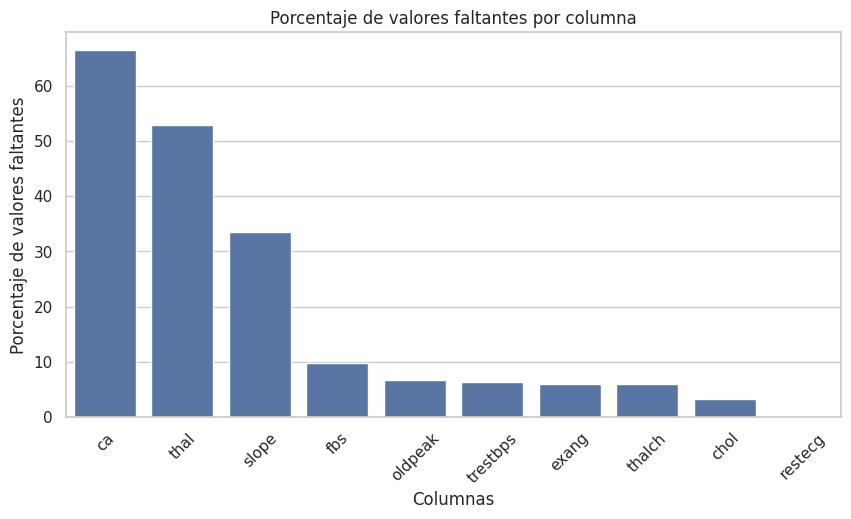

In [6]:
# Filtramos solo las columnas con valores faltantes
faltantes_grafico = tabla_faltantes[tabla_faltantes["valores_faltantes"] > 0]

# Creamos el gráfico
plt.figure(figsize=(10, 5))

sns.barplot(
    data=faltantes_grafico,
    x=faltantes_grafico.index,
    y="porcentaje"
)

plt.title("Porcentaje de valores faltantes por columna")
plt.xlabel("Columnas")
plt.ylabel("Porcentaje de valores faltantes")
plt.xticks(rotation=45)
plt.show()

### Comentario sobre la visualización de faltantes

El gráfico confirma lo que vimos en la tabla: los valores faltantes no están distribuidos de manera uniforme entre las columnas.

Las variables `ca`, `thal` y `slope` concentran la mayor proporción de datos ausentes, por lo que deben ser tratadas con especial cuidado. En cambio, otras columnas tienen porcentajes menores de faltantes y pueden ser abordadas mediante estrategias de imputación más simples dentro del pipeline.

En este proyecto vamos a conservar estas variables para mostrar cómo construir un flujo de preprocesamiento completo. Sin embargo, esta no es la única decisión posible. En otro análisis, podríamos comparar el rendimiento de modelos entrenados con todas las variables contra modelos entrenados sin las columnas con mayor cantidad de valores faltantes.

> **Sugerencia para tu proyecto:**  
> Una buena práctica es dejar registradas las decisiones tomadas. Si decidís conservar, eliminar o imputar una columna, explicá brevemente por qué lo hacés.

## Revisión de duplicados y valores únicos

Además de los valores faltantes, conviene revisar si existen filas duplicadas y observar los valores únicos de algunas columnas categóricas.

Los duplicados pueden afectar el entrenamiento del modelo, porque harían que algunos registros tengan más peso del que corresponde. Por otra parte, revisar los valores únicos permite detectar categorías inesperadas, errores de escritura o formatos inconsistentes.

En esta sección vamos a revisar:

- cantidad de filas duplicadas;
- valores únicos de las principales variables categóricas;
- distribución de la variable `dataset`, que indica el origen de cada registro.

> **Sugerencia para tu proyecto:**  
> En datasets reales, es común encontrar categorías escritas de formas diferentes, espacios extra, mayúsculas/minúsculas inconsistentes o valores inesperados. Revisar valores únicos ayuda a detectar estos problemas antes del modelado.

In [7]:
# Revisamos si existen filas duplicadas
duplicados = df.duplicated().sum()

print("Cantidad de filas duplicadas:")
print(duplicados)

print("\nValores únicos en columnas categóricas principales:")

columnas_categoricas_iniciales = [
    "sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"
]

for columna in columnas_categoricas_iniciales:
    print(f"\nColumna: {columna}")
    print(df[columna].unique())

Cantidad de filas duplicadas:
0

Valores únicos en columnas categóricas principales:

Columna: sex
['Male' 'Female']

Columna: dataset
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

Columna: cp
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

Columna: fbs
[True False nan]

Columna: restecg
['lv hypertrophy' 'normal' 'st-t abnormality' nan]

Columna: exang
[False True nan]

Columna: slope
['downsloping' 'flat' 'upsloping' nan]

Columna: thal
['fixed defect' 'normal' 'reversable defect' nan]


### Interpretación de duplicados y valores únicos

El dataset no presenta filas duplicadas, por lo que no es necesario eliminar registros repetidos en esta etapa.

Al revisar las variables categóricas, observamos que los valores parecen estar escritos de manera consistente. Por ejemplo, `sex` contiene solo `Male` y `Female`, y `cp` contiene cuatro categorías bien definidas para el tipo de dolor en el pecho.

También vemos que algunas columnas categóricas o booleanas incluyen valores faltantes, representados como `nan`. Esto ocurre en variables como `fbs`, `restecg`, `exang`, `slope` y `thal`.

En principio, no parece necesario corregir errores de escritura en las categorías. El principal trabajo de preparación estará relacionado con imputar valores faltantes y codificar estas variables para que puedan ser utilizadas por los modelos.

La columna `dataset` indica el origen de cada registro. En este proyecto podríamos conservarla como variable contextual o eliminarla si consideramos que no corresponde usarla como predictor. Más adelante tomaremos esa decisión al definir las variables del modelo.

> **Sugerencia para tu proyecto:**  
> Si encontrás categorías similares escritas de maneras distintas, como `"Male"`, `"male"` y `"M"`, conviene unificarlas antes de entrenar el modelo. Los algoritmos no interpretan automáticamente que esas variantes representan lo mismo.

## Análisis de la variable objetivo

En un proyecto supervisado de Machine Learning, la variable objetivo es la columna que queremos predecir.

En este dataset, la variable objetivo original es `num`. Esta columna indica el diagnóstico de enfermedad cardíaca con valores entre 0 y 4:

- `0`: ausencia de enfermedad cardíaca;
- `1`, `2`, `3` y `4`: distintos niveles de presencia de enfermedad cardíaca.

Para este proyecto vamos a simplificar el problema y convertirlo en una tarea de **clasificación binaria**. Es decir, no intentaremos predecir el grado exacto de enfermedad, sino distinguir entre dos clases:

- pacientes sin enfermedad cardíaca;
- pacientes con enfermedad cardíaca.

Antes de hacer esa transformación, vamos a revisar la distribución original de `num`.

> **Sugerencia para tu proyecto:**  
> Definir correctamente la variable objetivo es una de las decisiones más importantes del trabajo. Si la variable objetivo está mal elegida o mal interpretada, todo el modelo puede perder sentido.

In [8]:
# Revisamos la distribución original de la variable objetivo
df["num"].value_counts().sort_index()

,count
num,
0,411
1,265
2,109
3,107
4,28


### Interpretación de la variable objetivo original

La variable `num` contiene cinco valores posibles: `0`, `1`, `2`, `3` y `4`.

En este dataset hay:

- **411 pacientes** con valor `0`, es decir, sin enfermedad cardíaca registrada;
- **509 pacientes** con valores entre `1` y `4`, es decir, con algún grado de enfermedad cardíaca.

Aunque originalmente `num` permite distinguir distintos niveles de enfermedad, en este proyecto vamos a transformar esa información en una variable binaria. Esto nos permitirá trabajar con un problema más simple y adecuado para una primera guía completa de clasificación.

La nueva variable indicará:

- `0`: ausencia de enfermedad cardíaca;
- `1`: presencia de enfermedad cardíaca.

Esta transformación no significa que los distintos grados de enfermedad no sean importantes. Simplemente estamos tomando una decisión de modelado para enfocar el proyecto en clasificación binaria.

> **Sugerencia para tu proyecto:**  
> A veces una variable puede transformarse para adaptar el problema al objetivo del análisis. Por ejemplo, una variable con muchos niveles puede convertirse en binaria, o una variable numérica puede agruparse en categorías. Lo importante es justificar por qué se hace esa transformación.

## Creación de la variable objetivo binaria

Como vimos, la columna `num` tiene valores entre 0 y 4. Para este proyecto vamos a convertirla en una nueva variable llamada `enfermedad`.

La regla será la siguiente:

- si `num` es igual a `0`, entonces `enfermedad` será `0`;
- si `num` es mayor que `0`, entonces `enfermedad` será `1`.

De esta forma, el modelo no intentará predecir el nivel exacto de enfermedad, sino si existe o no presencia de enfermedad cardíaca.

Esta decisión nos permite trabajar con un problema de clasificación binaria, que es más simple de analizar y evaluar en un proyecto guía.

> **Sugerencia para tu proyecto:**  
> Cuando transformes la variable objetivo, explicá siempre la regla utilizada. No basta con mostrar el código: quien lea tu notebook tiene que entender qué representa cada clase.

In [9]:
# Creamos una nueva variable objetivo binaria
df["enfermedad"] = np.where(df["num"] == 0, 0, 1)

# Revisamos la distribución de la nueva variable objetivo
df["enfermedad"].value_counts()

,count
enfermedad,
1,509
0,411


### Interpretación de la variable objetivo binaria

Después de transformar `num`, la nueva variable `enfermedad` queda distribuida de la siguiente manera:

- `1`: 509 pacientes con presencia de enfermedad cardíaca;
- `0`: 411 pacientes sin enfermedad cardíaca.

La distribución entre clases no es perfectamente igual, pero tampoco parece extremadamente desbalanceada. Esto es importante porque, cuando una clase aparece mucho más que la otra, algunas métricas pueden ser engañosas.

Por ejemplo, en un dataset muy desbalanceado, un modelo podría lograr un accuracy alto simplemente prediciendo siempre la clase mayoritaria. En este caso, como las dos clases tienen una cantidad relativamente cercana de registros, el accuracy puede ser útil, pero igualmente vamos a complementarlo con otras métricas como precision, recall y F1-score.

> **Sugerencia para tu proyecto:**  
> Revisá siempre la distribución de la variable objetivo. Si una clase aparece mucho más que otra, no te quedes solo con el accuracy: analizá también recall, precision, F1-score y matriz de confusión.

## Visualización de la variable objetivo

Ahora vamos a representar gráficamente la distribución de la variable `enfermedad`.

Este gráfico nos permitirá ver de forma rápida cuántos pacientes hay en cada clase:

- `0`: sin enfermedad cardíaca;
- `1`: con enfermedad cardíaca.

Visualizar la variable objetivo es importante porque nos ayuda a detectar si el dataset está balanceado o si una clase aparece mucho más que la otra.

> **Sugerencia para tu proyecto:**  
> Siempre que trabajes con clasificación, graficá la distribución de la variable objetivo. Esto te ayudará a decidir qué métricas conviene usar para evaluar el modelo.

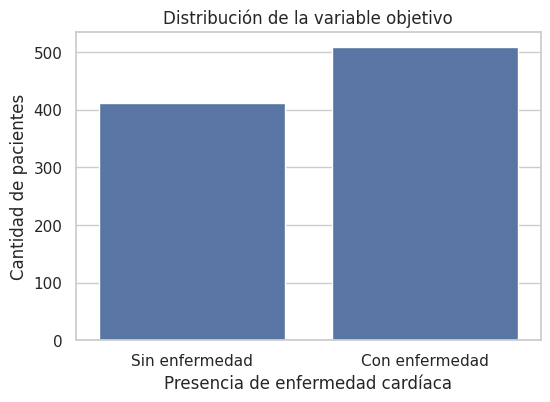

In [10]:
# Creamos un gráfico de barras para la variable objetivo
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="enfermedad"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Presencia de enfermedad cardíaca")
plt.ylabel("Cantidad de pacientes")
plt.xticks(
    ticks=[0, 1],
    labels=["Sin enfermedad", "Con enfermedad"]
)
plt.show()

### Comentario sobre la distribución de clases

El gráfico muestra que el dataset contiene más pacientes con presencia de enfermedad cardíaca que sin enfermedad, aunque la diferencia entre ambas clases no es extrema.

Esto significa que el problema no parece estar fuertemente desbalanceado, pero igualmente será importante evaluar los modelos con varias métricas. Más adelante no vamos a mirar solamente el accuracy, sino también precision, recall, F1-score, matriz de confusión y AUC.

En un contexto clínico, además, no todos los errores tienen el mismo impacto. Un falso negativo, es decir, predecir que un paciente no tiene enfermedad cuando sí la tiene, puede ser especialmente importante de analizar.

> **Sugerencia para tu proyecto:**  
> Cuando interpretes un gráfico, no te limites a describirlo. Tratá de explicar qué consecuencia puede tener esa observación para el modelado o para la evaluación del modelo.

## Análisis exploratorio de variables predictoras

Después de revisar la variable objetivo, vamos a explorar algunas variables que podrían ayudar al modelo a predecir la presencia de enfermedad cardíaca.

En esta etapa no buscamos todavía entrenar un modelo, sino entender mejor los datos. Vamos a observar algunas variables numéricas y categóricas para detectar patrones, diferencias entre grupos o posibles relaciones con la variable objetivo.

Algunas preguntas que pueden orientar esta exploración son:

- ¿La edad se distribuye igual entre pacientes con y sin enfermedad?
- ¿El tipo de dolor en el pecho parece estar relacionado con la presencia de enfermedad?
- ¿Hay diferencias visibles en variables como colesterol, presión arterial o frecuencia cardíaca?
- ¿Existen variables categóricas que parezcan separar mejor las clases?

> **Sugerencia para tu proyecto:**  
> No es necesario graficar todas las columnas del dataset. Elegí algunas variables relevantes y explicá por qué las analizás. Un buen EDA combina exploración técnica con interpretación.

In [11]:
# Identificamos columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identificamos columnas categóricas
columnas_categoricas = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

Columnas numéricas:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'enfermedad']

Columnas categóricas:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Interpretación de los tipos de variables

La separación automática de columnas nos muestra que el dataset contiene variables numéricas y categóricas.

Entre las columnas numéricas aparecen `age`, `trestbps`, `chol`, `thalch`, `oldpeak` y `ca`, que pueden aportar información clínica útil para el modelo.

También aparecen como numéricas `id`, `num` y `enfermedad`, pero estas columnas deben tratarse con cuidado:

- `id` es un identificador interno del paciente, por lo que no debería usarse como variable predictora;
- `num` es la variable objetivo original, que ya usamos para crear `enfermedad`;
- `enfermedad` es la nueva variable objetivo binaria que queremos predecir.

Por lo tanto, aunque `id`, `num` y `enfermedad` sean numéricas desde el punto de vista técnico, no las vamos a considerar como variables predictoras.

En las columnas categóricas encontramos variables como `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope` y `thal`. Estas variables deberán codificarse más adelante para que puedan ser utilizadas por los modelos.

> **Sugerencia para tu proyecto:**  
> No todas las columnas numéricas son automáticamente buenas predictoras. Algunas pueden ser identificadores, códigos internos o incluso versiones de la variable objetivo. Antes de usarlas, revisá qué representa cada columna.

In [12]:
# Definimos las variables numéricas clínicas que podrían usarse como predictoras
variables_numericas = [
    "age", "trestbps", "chol", "thalch", "oldpeak", "ca"
]

# Definimos las variables categóricas que podrían usarse como predictoras
variables_categoricas = [
    "sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"
]

print("Variables numéricas clínicas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas clínicas:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Variables categóricas:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## Exploración de variables numéricas

Ahora vamos a observar algunas variables numéricas del dataset y analizar si presentan diferencias entre pacientes con y sin enfermedad cardíaca.

Nos concentraremos en variables clínicas como:

- `age`: edad del paciente;
- `trestbps`: presión arterial en reposo;
- `chol`: colesterol;
- `thalch`: frecuencia cardíaca máxima alcanzada;
- `oldpeak`: depresión del segmento ST;
- `ca`: número de vasos principales coloreados por fluoroscopía.

Para comparar estas variables con la variable objetivo, usaremos gráficos de caja. Estos gráficos permiten observar la mediana, la dispersión y posibles valores extremos de cada variable según la presencia o ausencia de enfermedad.

> **Sugerencia para tu proyecto:**  
> Cuando compares variables numéricas con una variable objetivo categórica, los boxplots pueden ser muy útiles. Te permiten ver si los grupos presentan diferencias visibles, aunque esas diferencias después deban confirmarse con el modelo o con análisis más específicos.

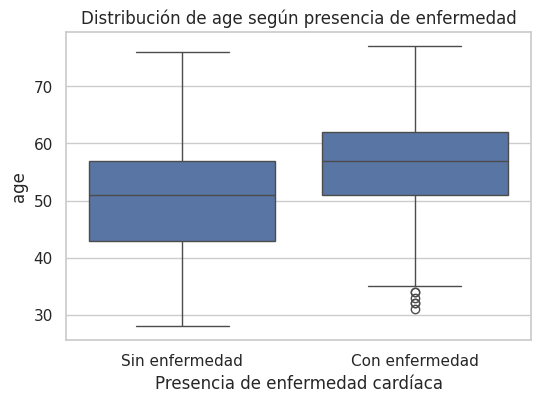

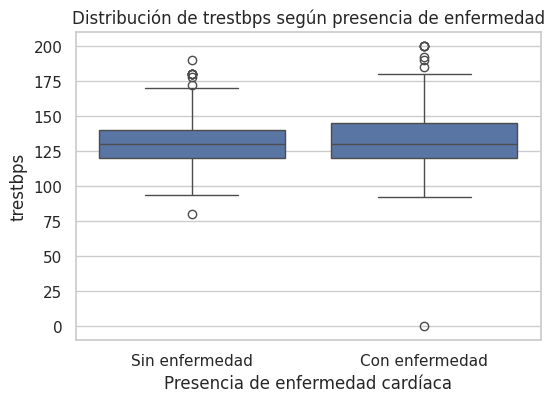

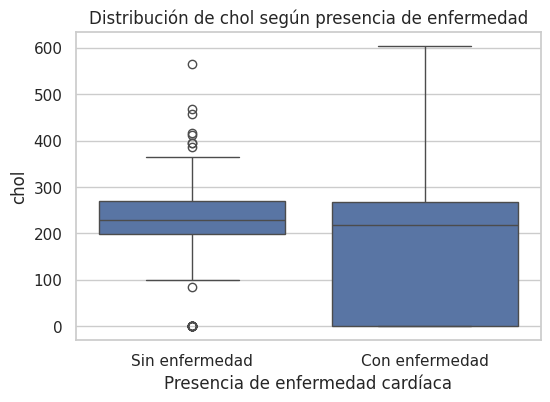

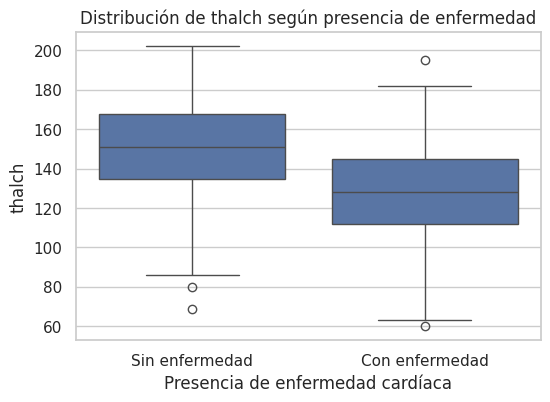

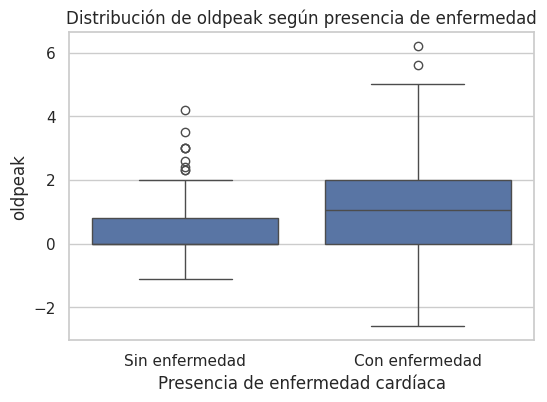

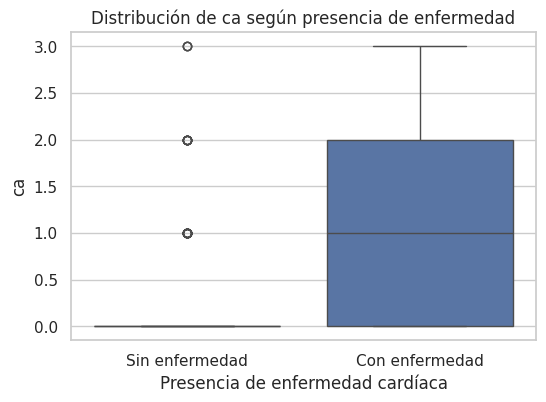

In [13]:
# Generamos boxplots para comparar variables numéricas según la variable objetivo
for variable in variables_numericas:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="enfermedad",
        y=variable
    )

    plt.title(f"Distribución de {variable} según presencia de enfermedad")
    plt.xlabel("Presencia de enfermedad cardíaca")
    plt.ylabel(variable)
    plt.xticks(
        ticks=[0, 1],
        labels=["Sin enfermedad", "Con enfermedad"]
    )
    plt.show()

### Interpretación de las variables numéricas

Los boxplots muestran que varias variables numéricas presentan diferencias visibles entre pacientes con y sin enfermedad cardíaca.

Esto sugiere que variables como `age`, `trestbps`, `chol`, `thalch`, `oldpeak` y `ca` podrían aportar información útil para el modelo. Sin embargo, es importante recordar que una diferencia visual no alcanza por sí sola para confirmar la importancia de una variable: más adelante el modelo ayudará a evaluar qué tan útiles resultan estas variables para predecir la clase objetivo.

También se observan algunos valores extremos o llamativos. Por ejemplo, en `chol` aparecen valores muy bajos, incluso cercanos a 0, lo cual puede ser sospechoso desde el punto de vista clínico. En un proyecto real, estos casos deberían revisarse con más detalle para decidir si representan errores de carga, datos faltantes codificados como 0 o registros válidos.

En este proyecto guía no vamos a eliminar esos valores manualmente en esta etapa, pero sí dejamos registrada la observación como parte del análisis exploratorio.

> **Sugerencia para tu proyecto:**  
> Cuando veas diferencias entre grupos en un gráfico, escribí qué observás y qué podría significar. También anotá valores raros o extremos, aunque decidas no modificarlos. Esa documentación mejora mucho la calidad del análisis.

## Resumen numérico por clase

Los gráficos nos permiten observar diferencias visuales entre pacientes con y sin enfermedad cardíaca. Para complementar esa mirada, vamos a calcular algunas estadísticas descriptivas agrupadas por la variable objetivo.

En particular, vamos a obtener el promedio de cada variable numérica para los dos grupos:

- pacientes sin enfermedad cardíaca;
- pacientes con enfermedad cardíaca.

Esto nos ayudará a expresar con números algunas diferencias que observamos en los boxplots.

> **Sugerencia para tu proyecto:**  
> Combinar gráficos con tablas resumen suele mejorar el análisis. El gráfico permite detectar patrones rápidamente, mientras que la tabla ayuda a precisar esas observaciones con valores concretos.

In [14]:
# Calculamos el promedio de las variables numéricas para cada clase
resumen_numerico = df.groupby("enfermedad")[variables_numericas].mean()

# Renombramos el índice para que sea más claro
resumen_numerico.index = ["Sin enfermedad", "Con enfermedad"]

# Mostramos la tabla
resumen_numerico

,age,trestbps,chol,thalch,oldpeak,ca
Sin enfermedad,50.547445,129.913043,227.905612,148.800512,0.418205,0.278788
Con enfermedad,55.903733,133.978723,176.479920,128.261603,1.262607,1.131944


### Interpretación del resumen numérico por clase

La tabla de promedios muestra algunas diferencias interesantes entre pacientes con y sin enfermedad cardíaca.

En promedio, los pacientes con enfermedad cardíaca tienen mayor edad que los pacientes sin enfermedad. También presentan valores promedio más altos en `oldpeak` y `ca`, dos variables que podrían aportar información relevante para el modelo.

La variable `thalch`, que representa la frecuencia cardíaca máxima alcanzada, muestra un promedio menor en pacientes con enfermedad. Esta diferencia también podría ser útil para distinguir entre ambas clases.

En el caso de `chol`, el promedio aparece más bajo en el grupo con enfermedad. Este resultado debe interpretarse con cuidado, porque anteriormente observamos valores muy bajos o incluso iguales a 0 en esta columna. Es posible que algunos de esos valores representen datos problemáticos o registros cargados de manera particular.

Estas observaciones no permiten concluir por sí solas qué variables serán más importantes, pero sí ayudan a entender mejor el comportamiento del dataset antes de entrenar modelos.

> **Sugerencia para tu proyecto:**  
> Cuando una tabla muestra un resultado inesperado, no lo ignores. Puede ser un patrón real, pero también puede deberse a valores faltantes, errores de carga, outliers o características particulares del dataset.

## Exploración de variables categóricas

Además de las variables numéricas, el dataset incluye varias variables categóricas que pueden aportar información importante al modelo.

Algunas de ellas describen características clínicas, como:

- `cp`: tipo de dolor en el pecho;
- `restecg`: resultado del electrocardiograma en reposo;
- `slope`: pendiente del segmento ST;
- `thal`: resultado de la prueba de talio;
- `exang`: presencia de angina inducida por ejercicio.

Otras describen características generales o de contexto, como `sex`, `fbs` y `dataset`.

En esta sección vamos a visualizar algunas de estas variables comparándolas con la variable objetivo `enfermedad`.

> **Sugerencia para tu proyecto:**  
> En variables categóricas, los gráficos de barras son una herramienta simple y útil. Te permiten ver si ciertas categorías aparecen con mayor frecuencia en una clase que en otra.

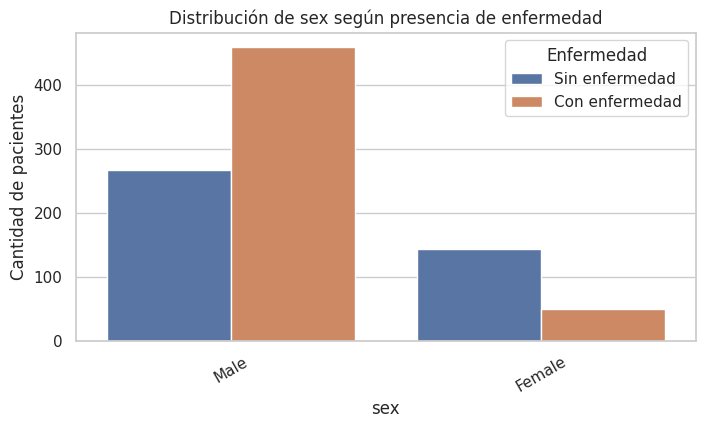

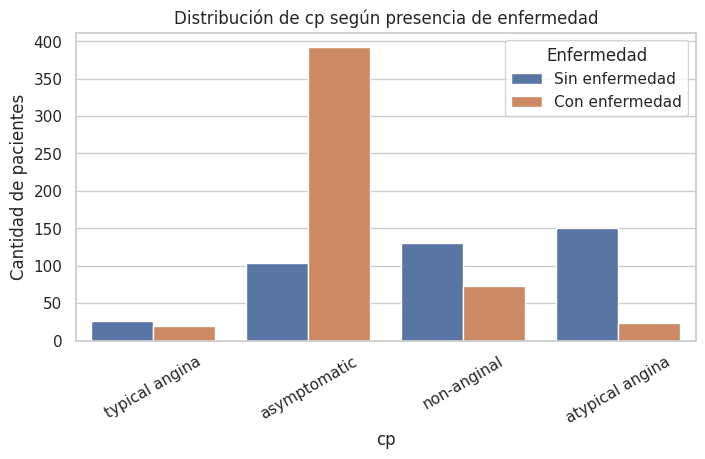

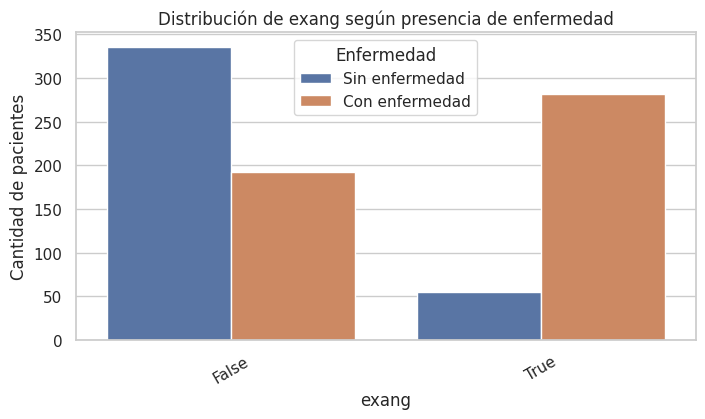

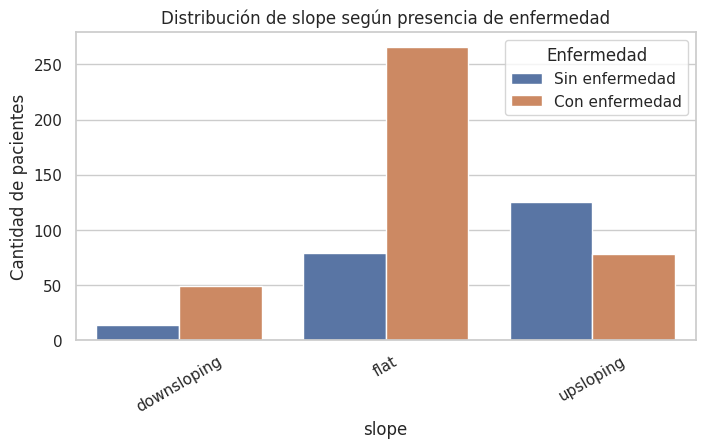

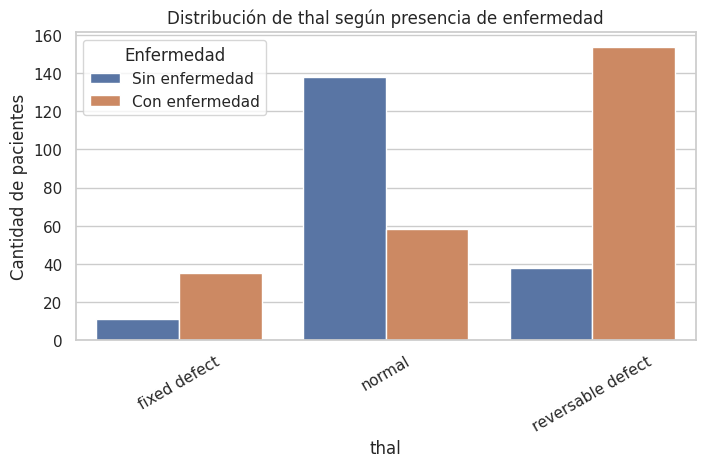

In [15]:
# Seleccionamos algunas variables categóricas para explorar
variables_categoricas_grafico = [
    "sex", "cp", "exang", "slope", "thal"
]

# Generamos gráficos de barras para cada variable categórica seleccionada
for variable in variables_categoricas_grafico:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=variable,
        hue="enfermedad"
    )

    plt.title(f"Distribución de {variable} según presencia de enfermedad")
    plt.xlabel(variable)
    plt.ylabel("Cantidad de pacientes")
    plt.legend(
        title="Enfermedad",
        labels=["Sin enfermedad", "Con enfermedad"]
    )
    plt.xticks(rotation=30)
    plt.show()

### Interpretación de las variables categóricas

Los gráficos de barras muestran que varias variables categóricas parecen estar relacionadas con la presencia o ausencia de enfermedad cardíaca.

En `cp`, que representa el tipo de dolor en el pecho, se observa una diferencia muy marcada: la categoría `asymptomatic` aparece con mucha mayor frecuencia en pacientes con enfermedad cardíaca. En cambio, otras categorías como `atypical angina` y `non-anginal` tienen mayor presencia relativa entre pacientes sin enfermedad.

En `exang`, que indica angina inducida por ejercicio, también se ve una diferencia clara. Los pacientes con `exang = True` aparecen mayoritariamente dentro del grupo con enfermedad cardíaca, mientras que `exang = False` es más frecuente entre pacientes sin enfermedad.

En `slope` y `thal` también aparecen patrones interesantes. Por ejemplo, algunas categorías como `flat` en `slope` o `reversable defect` en `thal` parecen asociarse con mayor presencia de enfermedad.

En `sex`, la distribución muestra una mayor cantidad de casos con enfermedad entre pacientes registrados como `Male`, mientras que en `Female` predominan los casos sin enfermedad. Esta observación debe interpretarse con cuidado, porque puede estar influida por la composición del dataset y no necesariamente representar una conclusión generalizable.

Estas diferencias sugieren que varias variables categóricas podrían ser útiles para el modelo. Más adelante las codificaremos para que puedan ser utilizadas por los algoritmos de Machine Learning.

> **Sugerencia para tu proyecto:**  
> Cuando una variable categórica muestre diferencias claras entre clases, señalalo en el análisis. Pero evitá convertir una observación visual en una conclusión absoluta: el gráfico muestra un patrón en este dataset, no una regla universal.

## Proporciones por categoría

Los gráficos de barras muestran cantidades absolutas. Sin embargo, a veces también conviene analizar proporciones o porcentajes.

Esto es útil porque una categoría puede tener muchos casos simplemente porque aparece mucho en el dataset. En cambio, las proporciones nos ayudan a ver qué porcentaje de cada categoría corresponde a pacientes con o sin enfermedad cardíaca.

En la siguiente celda vamos a calcular tablas de proporciones para algunas variables categóricas relevantes.

> **Sugerencia para tu proyecto:**  
> Cuando compares categorías, no mires solo cantidades absolutas. También revisá porcentajes, porque permiten comparar mejor grupos de distinto tamaño.

In [16]:
# Variables categóricas que vamos a analizar con proporciones
variables_proporciones = [
    "cp", "exang", "slope", "thal"
]

# Calculamos y mostramos una tabla de proporciones para cada variable
for variable in variables_proporciones:
    print(f"\nProporciones para la variable: {variable}")

    tabla_prop = pd.crosstab(
        df[variable],
        df["enfermedad"],
        normalize="index"
    ) * 100

    tabla_prop = tabla_prop.rename(
        columns={
            0: "Sin enfermedad (%)",
            1: "Con enfermedad (%)"
        }
    )

    display(tabla_prop.round(2))


Proporciones para la variable: cp


enfermedad,Sin enfermedad (%),Con enfermedad (%)
cp,,
asymptomatic,20.97,79.03
atypical angina,86.21,13.79
non-anginal,64.22,35.78
typical angina,56.52,43.48



Proporciones para la variable: exang


enfermedad,Sin enfermedad (%),Con enfermedad (%)
exang,,
False,63.64,36.36
True,16.32,83.68



Proporciones para la variable: slope


enfermedad,Sin enfermedad (%),Con enfermedad (%)
slope,,
downsloping,22.22,77.78
flat,22.90,77.10
upsloping,61.58,38.42



Proporciones para la variable: thal


enfermedad,Sin enfermedad (%),Con enfermedad (%)
thal,,
fixed defect,23.91,76.09
normal,70.41,29.59
reversable defect,19.79,80.21


### Interpretación de las proporciones por categoría

Las tablas de proporciones permiten observar con más precisión algunas relaciones entre variables categóricas y presencia de enfermedad cardíaca.

En la variable `cp`, la categoría `asymptomatic` presenta una proporción muy alta de pacientes con enfermedad cardíaca: aproximadamente **79%**. En cambio, en `atypical angina` solo alrededor del **14%** presenta enfermedad. Esto sugiere que el tipo de dolor en el pecho puede aportar información importante al modelo.

En `exang`, la diferencia también es marcada. Entre quienes presentan angina inducida por ejercicio (`True`), aproximadamente **84%** tiene enfermedad cardíaca. En cambio, entre quienes no la presentan (`False`), la proporción con enfermedad es mucho menor.

En `slope`, las categorías `downsloping` y `flat` muestran porcentajes altos de presencia de enfermedad, mientras que `upsloping` tiene una proporción menor.

En `thal`, la categoría `reversable defect` muestra una proporción de enfermedad cercana al **80%**, mientras que `normal` presenta una proporción mucho menor.

Estas observaciones refuerzan la idea de que varias variables categóricas pueden ser relevantes para el modelo. Sin embargo, todavía no estamos seleccionando variables de manera definitiva: por ahora estamos explorando patrones que luego el modelo podrá aprovechar.

> **Sugerencia para tu proyecto:**  
> Las proporciones ayudan a detectar variables prometedoras, pero no reemplazan la evaluación del modelo. Una variable puede parecer importante en el EDA y luego aportar poco al modelo, o al revés. Por eso conviene combinar exploración, entrenamiento y evaluación.

## Correlación entre variables numéricas

Otra forma de explorar el dataset es analizar la correlación entre variables numéricas.

La correlación permite observar si dos variables tienden a moverse juntas. Por ejemplo, si cuando una variable aumenta, otra también suele aumentar, o si cuando una aumenta, la otra tiende a disminuir.

En esta sección vamos a calcular una matriz de correlación para las variables numéricas clínicas y la variable objetivo binaria `enfermedad`.

Esto puede ayudarnos a detectar relaciones iniciales entre variables, aunque debemos interpretar los resultados con cuidado. La correlación muestra asociaciones lineales, pero no implica causalidad ni garantiza que una variable sea importante para el modelo.

> **Sugerencia para tu proyecto:**  
> Usá la matriz de correlación como una herramienta exploratoria, no como una prueba definitiva. Una correlación alta puede ser interesante, pero siempre debe analizarse dentro del contexto del problema.

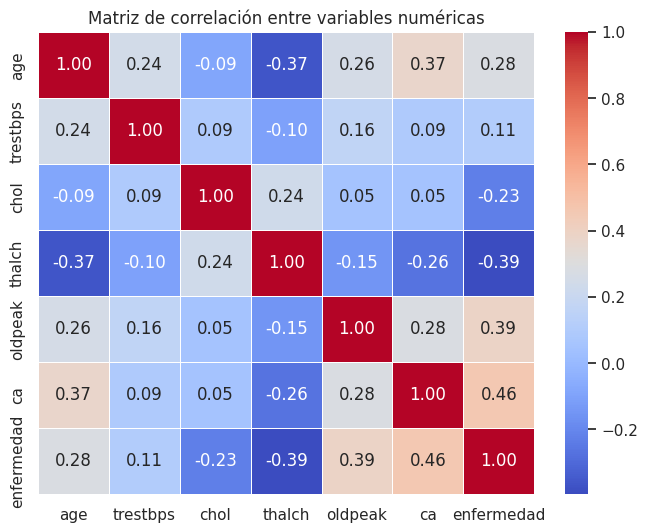

In [17]:
# Seleccionamos variables numéricas clínicas junto con la variable objetivo binaria
variables_correlacion = variables_numericas + ["enfermedad"]

# Calculamos la matriz de correlación
matriz_correlacion = df[variables_correlacion].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite observar qué variables numéricas tienen una relación lineal más marcada con la variable objetivo `enfermedad`.

En este caso, las correlaciones más destacadas con la presencia de enfermedad cardíaca son:

- `ca`: correlación positiva de aproximadamente **0.46**;
- `oldpeak`: correlación positiva de aproximadamente **0.39**;
- `thalch`: correlación negativa de aproximadamente **-0.39**;
- `age`: correlación positiva de aproximadamente **0.28**;
- `chol`: correlación negativa de aproximadamente **-0.23**.

Esto sugiere que valores más altos de `ca` y `oldpeak` tienden a asociarse con mayor presencia de enfermedad cardíaca, mientras que valores más altos de `thalch` tienden a asociarse con menor presencia de enfermedad.

La correlación de `chol` vuelve a ser un caso que debemos interpretar con cuidado. Aunque aparece una correlación negativa con `enfermedad`, ya observamos que esta variable contiene valores muy bajos o incluso iguales a 0, lo que puede afectar el análisis.

También es importante recordar que la correlación solo mide relaciones lineales entre variables numéricas. Algunas variables categóricas pueden ser muy importantes para el modelo, pero no aparecen en esta matriz porque todavía no fueron codificadas.

> **Sugerencia para tu proyecto:**  
> No uses la matriz de correlación como único criterio para seleccionar variables. Puede ayudarte a detectar relaciones iniciales, pero no reemplaza el análisis del contexto, el tratamiento de variables categóricas ni la evaluación posterior del modelo.

# Preparación de los datos para el modelo

Después del análisis exploratorio inicial, ya tenemos una idea más clara de la estructura del dataset, de la variable objetivo y de algunas relaciones posibles entre las variables predictoras y la presencia de enfermedad cardíaca.

Ahora vamos a preparar los datos para entrenar modelos de Machine Learning.

En esta etapa tomaremos algunas decisiones importantes:

- definiremos cuáles serán las variables predictoras;
- separaremos la variable objetivo;
- descartaremos columnas que no deben usarse como entrada del modelo;
- dividiremos los datos en entrenamiento y prueba;
- construiremos un pipeline de preprocesamiento.

No todas las columnas del dataset deben ingresar al modelo. En este caso, vamos a excluir:

- `id`, porque es un identificador interno;
- `num`, porque es la variable objetivo original;
- `enfermedad`, porque es la variable objetivo binaria que queremos predecir;
- `dataset`, porque indica el origen del registro y podría hacer que el modelo aprenda diferencias entre fuentes de datos en lugar de concentrarse en variables clínicas.

Esta última decisión podría discutirse. En algunos proyectos, una variable de origen puede ser útil. En este caso, preferimos no usarla para construir un modelo centrado en información clínica del paciente.

> **Sugerencia para tu proyecto:**  
> Antes de entrenar un modelo, revisá si hay columnas que no deberían usarse como predictoras. Algunas variables pueden parecer útiles, pero introducir sesgos, identificadores artificiales o información demasiado cercana a la variable objetivo.

In [18]:
# Definimos las columnas que no usaremos como predictoras
columnas_a_excluir = ["id", "num", "enfermedad", "dataset"]

# Creamos X con las variables predictoras
X = df.drop(columns=columnas_a_excluir)

# Creamos y con la variable objetivo
y = df["enfermedad"]

# Revisamos las dimensiones resultantes
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nColumnas predictoras:")
print(X.columns.tolist())

Dimensiones de X:
(920, 13)

Dimensiones de y:
(920,)

Columnas predictoras:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


### Interpretación de la selección de variables

Después de excluir las columnas `id`, `num`, `enfermedad` y `dataset`, el conjunto de variables predictoras queda formado por **13 columnas**.

Estas variables incluyen información clínica y demográfica del paciente, como edad, sexo, tipo de dolor en el pecho, presión arterial, colesterol, frecuencia cardíaca máxima, angina inducida por ejercicio y resultados de estudios médicos.

La variable objetivo `y` corresponde a `enfermedad`, que indica si el paciente presenta o no enfermedad cardíaca.

Esta separación entre `X` e `y` es fundamental:

- `X` contiene la información que el modelo usará para aprender;
- `y` contiene la respuesta correcta que el modelo intentará predecir.

También es importante destacar que no usamos `num` como predictora, porque de esa columna construimos la variable objetivo. Incluirla en `X` produciría fuga de información, ya que el modelo tendría acceso directo a una variable que revela la respuesta.

> **Sugerencia para tu proyecto:**  
> Antes de entrenar, revisá cuidadosamente que la variable objetivo no esté incluida entre las predictoras, ni tampoco alguna columna que revele indirectamente la respuesta. Ese error se conoce como fuga de información y puede hacer que el modelo parezca mucho mejor de lo que realmente es.

## División en entrenamiento y prueba

Antes de entrenar un modelo, necesitamos separar los datos en dos partes:

- un conjunto de entrenamiento, que el modelo usará para aprender patrones;
- un conjunto de prueba, que reservaremos para evaluar el rendimiento sobre datos que el modelo no vio durante el entrenamiento.

Esta separación es importante porque no queremos evaluar el modelo con los mismos datos que utilizó para aprender. Si lo hiciéramos, podríamos obtener resultados demasiado optimistas.

En este proyecto usaremos `train_test_split` para dividir los datos. Además, aplicaremos `stratify=y` para conservar una proporción similar de pacientes con y sin enfermedad en ambos conjuntos.

> **Sugerencia para tu proyecto:**  
> En problemas de clasificación, usar `stratify` suele ser una buena práctica, especialmente si las clases no tienen exactamente la misma cantidad de registros.

In [19]:
# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Revisamos las dimensiones de cada conjunto
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

# Revisamos la proporción de clases en entrenamiento y prueba
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Dimensiones de X_train: (644, 13)
Dimensiones de X_test: (276, 13)
Dimensiones de y_train: (644,)
Dimensiones de y_test: (276,)

Distribución de clases en entrenamiento:
enfermedad
1    0.553
0    0.447
Name: proportion, dtype: float64

Distribución de clases en prueba:
enfermedad
1    0.554
0    0.446
Name: proportion, dtype: float64


### Interpretación de la división de datos

El dataset quedó dividido en:

- **644 registros** para entrenamiento;
- **276 registros** para prueba.

Esto corresponde a una división aproximada de 70% para entrenamiento y 30% para prueba.

Además, la distribución de clases se mantiene prácticamente igual en ambos conjuntos:

- en entrenamiento, aproximadamente 55.3% de los casos corresponden a pacientes con enfermedad y 44.7% a pacientes sin enfermedad;
- en prueba, aproximadamente 55.4% de los casos corresponden a pacientes con enfermedad y 44.6% a pacientes sin enfermedad.

Esto confirma que `stratify=y` funcionó correctamente. Gracias a eso, el modelo será entrenado y evaluado sobre conjuntos que conservan una proporción similar de clases.

> **Sugerencia para tu proyecto:**  
> Después de dividir los datos, verificá siempre las dimensiones y la distribución de clases. No alcanza con aplicar `train_test_split`: también hay que confirmar que la separación tenga sentido.

## Construcción del pipeline de preprocesamiento

Antes de entrenar modelos, necesitamos transformar los datos para que puedan ser interpretados correctamente por los algoritmos de Machine Learning.

Nuestro dataset contiene dos tipos principales de variables:

- variables numéricas, que pueden tener valores faltantes y diferentes escalas;
- variables categóricas, que deben convertirse a formato numérico antes de ingresar al modelo.

Para resolver esto de manera ordenada, vamos a construir un pipeline de preprocesamiento.

El pipeline aplicará distintas transformaciones según el tipo de variable:

- para variables numéricas:
  - imputación de valores faltantes usando la mediana;
  - estandarización con `StandardScaler`;

- para variables categóricas:
  - imputación de valores faltantes usando la categoría más frecuente;
  - codificación con `OneHotEncoder`.

Usaremos `ColumnTransformer` para aplicar cada transformación al grupo de columnas correspondiente.

> **Sugerencia para tu proyecto:**  
> Un pipeline ayuda a evitar errores y hace que el flujo de trabajo sea más claro y reutilizable. Además, permite aplicar las transformaciones de forma consistente sobre entrenamiento, prueba y validación cruzada.

In [20]:
# Identificamos las columnas numéricas dentro de X
columnas_numericas_modelo = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identificamos las columnas categóricas dentro de X
columnas_categoricas_modelo = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Columnas numéricas para el modelo:")
print(columnas_numericas_modelo)

print("\nColumnas categóricas para el modelo:")
print(columnas_categoricas_modelo)

Columnas numéricas para el modelo:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Columnas categóricas para el modelo:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Interpretación de las columnas para el preprocesamiento

Las columnas quedaron separadas en dos grupos:

**Variables numéricas:**

- `age`
- `trestbps`
- `chol`
- `thalch`
- `oldpeak`
- `ca`

Estas variables pueden tener valores faltantes y escalas diferentes. Por eso, en el pipeline vamos a imputar sus valores faltantes y luego estandarizarlas.

**Variables categóricas:**

- `sex`
- `cp`
- `fbs`
- `restecg`
- `exang`
- `slope`
- `thal`

Estas variables contienen categorías o valores booleanos. Para que puedan ser utilizadas por los modelos, vamos a imputar sus valores faltantes y luego convertirlas en variables numéricas mediante codificación one-hot.

La columna `dataset` ya no aparece porque decidimos excluirla como variable predictora.

> **Sugerencia para tu proyecto:**  
> Antes de crear un pipeline, verificá qué columnas entran en cada grupo de transformación. Si una columna queda en el grupo equivocado, el modelo puede fallar o aprender a partir de datos mal preparados.

In [21]:
# Transformador para variables numéricas
transformador_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ]
)

# Transformador para variables categóricas
transformador_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore"))
    ]
)

print("Transformador numérico creado:")
print(transformador_numerico)

print("\nTransformador categórico creado:")
print(transformador_categorico)

Transformador numérico creado:
Pipeline(steps=[('imputador', SimpleImputer(strategy='median')),
                ('escalador', StandardScaler())])

Transformador categórico creado:
Pipeline(steps=[('imputador', SimpleImputer(strategy='most_frequent')),
                ('codificador', OneHotEncoder(handle_unknown='ignore'))])


### Interpretación de los transformadores

Creamos dos pipelines de preprocesamiento:

El `transformador_numerico` se aplicará a las variables numéricas. Primero reemplazará los valores faltantes usando la mediana de cada columna y luego estandarizará los valores con `StandardScaler`.

El `transformador_categorico` se aplicará a las variables categóricas. Primero reemplazará los valores faltantes usando la categoría más frecuente y luego convertirá las categorías en columnas numéricas mediante `OneHotEncoder`.

Los nombres `"imputador"`, `"escalador"` y `"codificador"` son etiquetas internas del pipeline. Sirven para identificar cada paso dentro del flujo de procesamiento.

> **Sugerencia para tu proyecto:**  
> Cuando uses pipelines, elegí nombres claros para cada paso. No cambian el cálculo, pero ayudan a leer, revisar y reutilizar el código.

In [22]:
# Construimos el preprocesador general
preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", transformador_numerico, columnas_numericas_modelo),
        ("categoricas", transformador_categorico, columnas_categoricas_modelo)
    ]
)

print("Preprocesador creado:")
print(preprocesamiento)

Preprocesador creado:
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak', 'ca']),
                                ('categoricas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('codificador',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'thal'])])


### Interpretación del preprocesador

El objeto `preprocesamiento` integra todas las transformaciones necesarias antes de entrenar los modelos.

Este preprocesador aplicará:

- el pipeline numérico a las columnas numéricas;
- el pipeline categórico a las columnas categóricas.

Esto significa que cada grupo de variables recibirá el tratamiento adecuado según su tipo de dato.

Una ventaja importante de usar `ColumnTransformer` es que no necesitamos transformar manualmente cada columna. El preprocesador se encargará de aplicar cada paso en el orden correcto.

Además, al integrarlo luego dentro de un pipeline completo junto con el modelo, evitamos aplicar transformaciones por separado sobre entrenamiento y prueba. Esto ayuda a reducir errores y mejora la reproducibilidad del trabajo.

> **Sugerencia para tu proyecto:**  
> Si tu dataset tiene distintos tipos de variables, no intentes aplicar la misma transformación a todas. Separar columnas numéricas y categóricas permite preparar los datos de manera más adecuada.

# Entrenamiento de modelos

Ya tenemos definidos:

- `X_train` y `X_test`, con las variables predictoras;
- `y_train` y `y_test`, con la variable objetivo;
- `preprocesamiento`, que contiene todos los pasos necesarios para preparar los datos.

Ahora vamos a entrenar modelos de clasificación.

En este proyecto vamos a comenzar con **Regresión Logística**, un modelo simple, rápido y relativamente interpretable. Luego entrenaremos también un **Random Forest**, que es un modelo más flexible y capaz de capturar relaciones más complejas.

La idea no es quedarnos con el primer resultado, sino comparar distintos modelos y justificar cuál parece más adecuado para este problema.

> **Sugerencia para tu proyecto:**  
> Es recomendable probar al menos dos modelos distintos. Por ejemplo, uno más simple e interpretable y otro más potente o flexible. Esto permite comparar resultados y tomar una decisión mejor fundamentada.

In [23]:
# Creamos el pipeline completo con Regresión Logística
pipeline_logistica = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Entrenamos el modelo con los datos de entrenamiento
pipeline_logistica.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


### Primer modelo entrenado: Regresión Logística

Ya entrenamos el primer modelo del proyecto: una **Regresión Logística**.

Este modelo recibió como entrada el conjunto de entrenamiento `X_train` y aprendió a relacionar las variables clínicas con la variable objetivo `y_train`, que indica si el paciente presenta o no enfermedad cardíaca.

Como el pipeline incluye tanto el preprocesamiento como el modelo, al ejecutar `fit()` ocurrieron dos cosas:

1. primero se aplicaron las transformaciones necesarias sobre los datos de entrenamiento;
2. luego se entrenó la Regresión Logística con esos datos ya preparados.

Todavía no sabemos qué tan bien funciona el modelo. Para eso necesitamos usarlo sobre el conjunto de prueba y calcular métricas de evaluación.

> **Sugerencia para tu proyecto:**  
> Entrenar un modelo no alcanza. Siempre necesitás evaluarlo con datos que no haya visto durante el entrenamiento. Esa evaluación es la que permite estimar si el modelo aprendió patrones útiles o si simplemente se ajustó demasiado a los datos de entrenamiento.

## Predicciones con el modelo de Regresión Logística

Una vez entrenado el modelo, podemos usarlo para realizar predicciones sobre el conjunto de prueba.

El conjunto de prueba contiene datos que el modelo no utilizó durante el entrenamiento. Por eso, nos permite evaluar de manera más realista cómo podría comportarse frente a nuevos pacientes.

En la siguiente celda vamos a generar las predicciones de la Regresión Logística sobre `X_test` y las guardaremos en una variable llamada `y_pred_logistica`.

Luego compararemos esas predicciones con los valores reales de `y_test`.

> **Sugerencia para tu proyecto:**  
> Separá claramente el entrenamiento de la evaluación. Primero entrená con `X_train` e `y_train`; después predecí sobre `X_test`; finalmente compará las predicciones con `y_test`.

In [24]:
# Generamos predicciones sobre el conjunto de prueba
y_pred_logistica = pipeline_logistica.predict(X_test)

# Mostramos las primeras predicciones
print("Primeras predicciones del modelo:")
print(y_pred_logistica[:20])

print("\nPrimeros valores reales:")
print(y_test.values[:20])

Primeras predicciones del modelo:
[1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0]

Primeros valores reales:
[1 0 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0]


### Primera comparación entre predicciones y valores reales

Al comparar las primeras predicciones con los primeros valores reales, vemos que el modelo acierta en varios casos, pero también comete algunos errores.

Por ejemplo, en algunos registros el modelo predice `1` cuando el valor real es `0`, o predice `0` cuando el valor real es `1`.

Esto es esperable: un modelo de Machine Learning rara vez acierta todos los casos. Lo importante ahora es medir su rendimiento de manera ordenada usando métricas de clasificación.

En la siguiente sección vamos a calcular métricas como accuracy, precision, recall y F1-score. También construiremos una matriz de confusión para analizar no solo cuántos errores comete el modelo, sino qué tipo de errores comete.

> **Sugerencia para tu proyecto:**  
> No evalúes un modelo mirando solo algunas predicciones sueltas. Esa comparación inicial sirve para entender qué está pasando, pero la evaluación real debe hacerse con métricas calculadas sobre todo el conjunto de prueba.

## Evaluación del modelo de Regresión Logística

Ahora vamos a evaluar el rendimiento del modelo sobre el conjunto de prueba.

Para eso calcularemos cuatro métricas principales:

- **accuracy**: proporción total de predicciones correctas;
- **precision**: de los casos que el modelo predijo como positivos, cuántos eran realmente positivos;
- **recall**: de los casos positivos reales, cuántos logró detectar el modelo;
- **F1-score**: métrica que combina precision y recall en un único valor.

En un problema clínico, no conviene mirar una sola métrica. Por ejemplo, un buen accuracy puede ocultar errores importantes si el modelo falla al detectar pacientes que sí tienen enfermedad.

> **Sugerencia para tu proyecto:**  
> Elegí las métricas según el tipo de problema. Para clasificación, podés usar accuracy, precision, recall, F1-score y matriz de confusión. Para regresión, en cambio, usarías métricas como MAE, RMSE o R².

In [25]:
# Calculamos métricas de evaluación para Regresión Logística
accuracy_logistica = accuracy_score(y_test, y_pred_logistica)
precision_logistica = precision_score(y_test, y_pred_logistica)
recall_logistica = recall_score(y_test, y_pred_logistica)
f1_logistica = f1_score(y_test, y_pred_logistica)

print("Métricas de Regresión Logística")
print("-------------------------------")
print(f"Accuracy:  {accuracy_logistica:.3f}")
print(f"Precision: {precision_logistica:.3f}")
print(f"Recall:    {recall_logistica:.3f}")
print(f"F1-score:  {f1_logistica:.3f}")

Métricas de Regresión Logística
-------------------------------
Accuracy:  0.826
Precision: 0.839
Recall:    0.850
F1-score:  0.844


### Interpretación de las métricas de Regresión Logística

El modelo de Regresión Logística obtuvo los siguientes resultados sobre el conjunto de prueba:

- **Accuracy:** 0.826  
- **Precision:** 0.839  
- **Recall:** 0.850  
- **F1-score:** 0.844  

El accuracy indica que el modelo clasificó correctamente aproximadamente el **82.6%** de los casos del conjunto de prueba.

La precision de **0.839** significa que, cuando el modelo predijo presencia de enfermedad cardíaca, acertó en una proporción alta de esos casos.

El recall de **0.850** indica que el modelo logró detectar aproximadamente el **85%** de los pacientes que realmente tenían enfermedad cardíaca.

El F1-score de **0.844** muestra un buen equilibrio entre precision y recall.

En conjunto, estos resultados sugieren que la Regresión Logística ofrece un rendimiento inicial sólido para este problema. Sin embargo, todavía necesitamos analizar la matriz de confusión para entender mejor qué tipo de errores está cometiendo el modelo.

> **Sugerencia para tu proyecto:**  
> No informes las métricas como números aislados. Explicá qué significa cada una en el contexto del problema. En clasificación médica, por ejemplo, el recall puede ser especialmente importante porque se relaciona con la capacidad del modelo para detectar casos positivos reales.

## Matriz de confusión de la Regresión Logística

Las métricas generales nos dan una primera idea del rendimiento del modelo, pero no nos muestran exactamente qué tipo de errores está cometiendo.

Para eso usamos la **matriz de confusión**.

En un problema de clasificación binaria, la matriz de confusión permite distinguir entre:

- verdaderos negativos: casos sin enfermedad correctamente clasificados;
- falsos positivos: casos sin enfermedad que el modelo clasificó como con enfermedad;
- falsos negativos: casos con enfermedad que el modelo clasificó como sin enfermedad;
- verdaderos positivos: casos con enfermedad correctamente clasificados.

En este contexto, los falsos negativos son especialmente importantes, porque representan pacientes que realmente tienen enfermedad cardíaca pero que el modelo no detecta.

> **Sugerencia para tu proyecto:**  
> La matriz de confusión ayuda a interpretar los errores del modelo. No todos los errores tienen el mismo impacto: depende del problema que estés resolviendo.

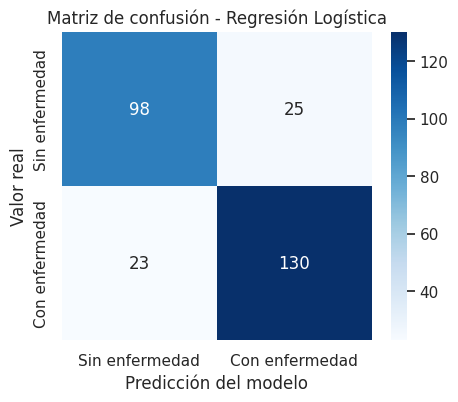

In [26]:
# Calculamos la matriz de confusión
matriz_logistica = confusion_matrix(y_test, y_pred_logistica)

# Visualizamos la matriz de confusión
plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_logistica,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin enfermedad", "Con enfermedad"],
    yticklabels=["Sin enfermedad", "Con enfermedad"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión de la Regresión Logística muestra los siguientes resultados:

- **98 verdaderos negativos:** pacientes sin enfermedad correctamente clasificados como sin enfermedad.
- **130 verdaderos positivos:** pacientes con enfermedad correctamente clasificados como con enfermedad.
- **25 falsos positivos:** pacientes sin enfermedad que el modelo clasificó como con enfermedad.
- **23 falsos negativos:** pacientes con enfermedad que el modelo clasificó como sin enfermedad.

En total, el modelo cometió **48 errores** sobre el conjunto de prueba: 25 falsos positivos y 23 falsos negativos.

Desde el punto de vista clínico, los falsos negativos merecen especial atención, porque representan pacientes que realmente tienen enfermedad cardíaca pero que el modelo no detectó. En este caso, hubo 23 falsos negativos.

También hubo 25 falsos positivos. Estos casos podrían generar estudios adicionales innecesarios, preocupación o revisiones médicas extra, pero en muchos contextos clínicos suelen considerarse menos graves que no detectar una enfermedad existente.

En general, la matriz confirma que el modelo tiene un rendimiento razonablemente equilibrado: detecta bien muchos casos positivos y negativos, aunque todavía comete errores que deben ser analizados.

> **Sugerencia para tu proyecto:**  
> Al interpretar una matriz de confusión, no te limites a decir cuántos aciertos hubo. Prestá atención al tipo de error más importante para tu problema. En salud, seguridad o fraude, algunos errores pueden ser mucho más costosos que otros.

## Entrenamiento de un segundo modelo: Random Forest

Para comparar resultados, vamos a entrenar un segundo modelo: **Random Forest**.

Random Forest es un modelo basado en muchos árboles de decisión. Cada árbol aprende ciertas reglas a partir de los datos, y luego el conjunto de árboles realiza una predicción combinada.

A diferencia de la Regresión Logística, Random Forest puede capturar relaciones más complejas entre las variables. Sin embargo, suele ser menos fácil de interpretar, porque su decisión final depende de muchos árboles trabajando en conjunto.

En este caso vamos a usar el mismo preprocesamiento que antes, pero cambiando el modelo final del pipeline.

> **Sugerencia para tu proyecto:**  
> Cuando compares modelos, intentá mantener el mismo conjunto de entrenamiento, el mismo conjunto de prueba y las mismas métricas. Así la comparación será más justa.

In [27]:
# Creamos el pipeline completo con Random Forest
pipeline_rf = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Entrenamos el modelo con los datos de entrenamiento
pipeline_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


### Segundo modelo entrenado: Random Forest

Ya entrenamos el segundo modelo del proyecto: un **Random Forest**.

Al igual que en el caso anterior, el pipeline combina dos partes:

1. el preprocesamiento de los datos;
2. el modelo de clasificación.

Esto significa que Random Forest recibió los datos ya imputados, codificados y preparados para el entrenamiento.

Aunque Random Forest no necesita escalado de variables de la misma manera que la Regresión Logística, en este cuaderno usamos el mismo preprocesamiento para mantener una estructura común y facilitar la comparación entre modelos.

El siguiente paso será generar predicciones sobre el conjunto de prueba y evaluar su rendimiento con las mismas métricas que usamos para la Regresión Logística.

> **Sugerencia para tu proyecto:**  
> Algunos modelos necesitan ciertas transformaciones más que otros. Por ejemplo, Regresión Logística y KNN suelen beneficiarse del escalado, mientras que Random Forest no depende tanto de la escala. Aun así, usar pipelines permite mantener un flujo ordenado y comparable.

In [28]:
# Generamos predicciones sobre el conjunto de prueba
y_pred_rf = pipeline_rf.predict(X_test)

# Mostramos las primeras predicciones
print("Primeras predicciones del modelo Random Forest:")
print(y_pred_rf[:20])

print("\nPrimeros valores reales:")
print(y_test.values[:20])

Primeras predicciones del modelo Random Forest:
[1 0 1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0]

Primeros valores reales:
[1 0 1 1 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0]


### Primera comparación de predicciones de Random Forest

Al observar las primeras predicciones de Random Forest junto con los valores reales, vemos que el modelo acierta varios casos del conjunto de prueba.

Sin embargo, al igual que ocurrió con la Regresión Logística, esta comparación inicial solo sirve como una primera revisión. Para evaluar correctamente el modelo necesitamos calcular métricas sobre todo el conjunto de prueba.

A continuación vamos a calcular accuracy, precision, recall y F1-score para Random Forest. Luego podremos comparar estos valores con los obtenidos por la Regresión Logística.

> **Sugerencia para tu proyecto:**  
> Cuando pruebes varios modelos, evaluá todos con las mismas métricas y sobre el mismo conjunto de prueba. Así la comparación será más clara y justa.

In [29]:
# Calculamos métricas de evaluación para Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Métricas de Random Forest")
print("-------------------------")
print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1-score:  {f1_rf:.3f}")

Métricas de Random Forest
-------------------------
Accuracy:  0.830
Precision: 0.844
Recall:    0.850
F1-score:  0.847


### Interpretación de las métricas de Random Forest

El modelo Random Forest obtuvo los siguientes resultados sobre el conjunto de prueba:

- **Accuracy:** 0.830  
- **Precision:** 0.844  
- **Recall:** 0.850  
- **F1-score:** 0.847  

Estos valores indican que Random Forest tuvo un rendimiento sólido. El accuracy muestra que clasificó correctamente aproximadamente el **83%** de los casos del conjunto de prueba.

La precision de **0.844** indica que, cuando el modelo predijo presencia de enfermedad cardíaca, acertó en una proporción alta de los casos.

El recall de **0.850** muestra que logró detectar aproximadamente el **85%** de los pacientes que realmente tenían enfermedad cardíaca.

El F1-score de **0.847** refleja un buen equilibrio entre precision y recall.

Si comparamos estos resultados con los de Regresión Logística, vemos que Random Forest mejora levemente en accuracy, precision y F1-score, mientras que el recall queda igual. Sin embargo, la diferencia entre ambos modelos es pequeña, por lo que todavía no alcanza para tomar una decisión final.

Para completar la evaluación, vamos a revisar también la matriz de confusión de Random Forest.

> **Sugerencia para tu proyecto:**  
> Si dos modelos tienen métricas muy parecidas, no elijas automáticamente el que mejora por unas pocas milésimas. También considerá interpretabilidad, estabilidad, facilidad de explicación y tipo de errores cometidos.

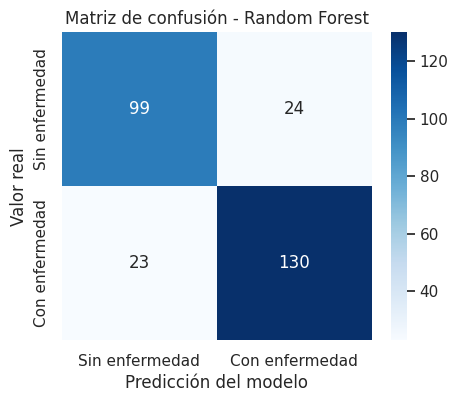

In [30]:
# Calculamos la matriz de confusión
matriz_rf = confusion_matrix(y_test, y_pred_rf)

# Visualizamos la matriz de confusión
plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin enfermedad", "Con enfermedad"],
    yticklabels=["Sin enfermedad", "Con enfermedad"]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

### Interpretación de la matriz de confusión de Random Forest

La matriz de confusión de Random Forest muestra los siguientes resultados:

- **99 verdaderos negativos:** pacientes sin enfermedad correctamente clasificados como sin enfermedad.
- **130 verdaderos positivos:** pacientes con enfermedad correctamente clasificados como con enfermedad.
- **24 falsos positivos:** pacientes sin enfermedad que el modelo clasificó como con enfermedad.
- **23 falsos negativos:** pacientes con enfermedad que el modelo clasificó como sin enfermedad.

En comparación con la Regresión Logística, Random Forest mantiene la misma cantidad de verdaderos positivos y falsos negativos, pero mejora levemente en la clasificación de pacientes sin enfermedad: tiene un falso positivo menos.

Esto explica por qué sus métricas son apenas superiores, aunque la diferencia entre ambos modelos sigue siendo muy pequeña.

Desde el punto de vista clínico, ambos modelos dejan sin detectar la misma cantidad de pacientes con enfermedad: **23 falsos negativos**. Por eso, si nuestro criterio principal fuera reducir falsos negativos, Random Forest no ofrece una mejora clara frente a la Regresión Logística en esta evaluación.

> **Sugerencia para tu proyecto:**  
> Cuando compares modelos, mirá también la matriz de confusión. Dos modelos pueden tener métricas generales muy parecidas, pero cometer errores distintos. Esa diferencia puede ser importante según el contexto del problema.

## Comparación de modelos

Ya entrenamos y evaluamos dos modelos:

- Regresión Logística;
- Random Forest.

Ambos modelos fueron entrenados con el mismo conjunto de entrenamiento, evaluados con el mismo conjunto de prueba y medidos con las mismas métricas. Esto nos permite hacer una comparación más ordenada.

Ahora vamos a construir una tabla comparativa con las principales métricas de cada modelo:

- accuracy;
- precision;
- recall;
- F1-score.

Esta tabla nos ayudará a decidir si alguno de los modelos ofrece una ventaja clara sobre el otro.

> **Sugerencia para tu proyecto:**  
> Una tabla comparativa facilita mucho la lectura de resultados. En lugar de dejar métricas sueltas en distintas partes del notebook, conviene reunirlas en un mismo lugar para poder analizarlas en conjunto.

In [31]:
# Creamos una tabla comparativa de métricas
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_logistica, accuracy_rf],
    "Precision": [precision_logistica, precision_rf],
    "Recall": [recall_logistica, recall_rf],
    "F1-score": [f1_logistica, f1_rf]
})

# Mostramos la tabla con valores redondeados
comparacion_modelos.round(3)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.826,0.839,0.85,0.844
1,Random Forest,0.830,0.844,0.85,0.847


### Interpretación de la comparación de modelos

La tabla comparativa muestra que ambos modelos tienen un rendimiento muy similar.

Random Forest obtiene valores apenas superiores en algunas métricas:

- Accuracy: 0.830 frente a 0.826 de Regresión Logística.
- Precision: 0.844 frente a 0.839.
- F1-score: 0.847 frente a 0.844.

El recall es igual en ambos modelos: **0.850**. Esto significa que los dos modelos detectan la misma proporción de pacientes que realmente tienen enfermedad cardíaca.

Aunque Random Forest tiene una mejora leve, la diferencia no parece lo suficientemente grande como para elegirlo automáticamente. También debemos considerar otros aspectos, como la interpretabilidad. La Regresión Logística suele ser más fácil de explicar, mientras que Random Forest puede capturar relaciones más complejas, pero resulta menos transparente.

En este punto, podemos decir que ambos modelos son candidatos razonables. Para tomar una decisión más fundamentada, vamos a complementar la evaluación con validación cruzada.

> **Sugerencia para tu proyecto:**  
> Cuando dos modelos tienen métricas muy parecidas, no elijas solo por el número más alto. Pensá también en la facilidad de explicación, el tipo de error que comete cada modelo y la utilidad práctica en el contexto del problema.

## Validación cruzada

Hasta ahora evaluamos los modelos usando una única división entre entrenamiento y prueba. Esa evaluación es útil, pero depende de una partición específica del dataset.

Para obtener una estimación más robusta del rendimiento, vamos a aplicar **validación cruzada**.

La validación cruzada divide el conjunto de datos en varias partes o *folds*. El modelo se entrena varias veces, usando distintas particiones para entrenar y validar. Luego se calcula un promedio de los resultados obtenidos.

En este proyecto usaremos validación cruzada con 5 particiones y compararemos el accuracy promedio de ambos modelos.

Es importante destacar que, como nuestros modelos están construidos dentro de pipelines, en cada partición se aplicará también el preprocesamiento correspondiente. Esto ayuda a evitar errores y mantiene el flujo de trabajo ordenado.

> **Sugerencia para tu proyecto:**  
> La validación cruzada no reemplaza por completo al conjunto de prueba, pero ayuda a saber si el rendimiento del modelo es estable o si depende demasiado de una división particular de los datos.

In [32]:
# Importamos StratifiedKFold para mantener proporciones de clase en cada partición
from sklearn.model_selection import StratifiedKFold

# Definimos la estrategia de validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Validación cruzada para Regresión Logística
cv_logistica = cross_val_score(
    pipeline_logistica,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Validación cruzada para Random Forest
cv_rf = cross_val_score(
    pipeline_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Validación cruzada - Regresión Logística")
print("----------------------------------------")
print("Resultados por fold:", cv_logistica.round(3))
print(f"Accuracy promedio: {cv_logistica.mean():.3f}")
print(f"Desvío estándar:   {cv_logistica.std():.3f}")

print("\nValidación cruzada - Random Forest")
print("----------------------------------")
print("Resultados por fold:", cv_rf.round(3))
print(f"Accuracy promedio: {cv_rf.mean():.3f}")
print(f"Desvío estándar:   {cv_rf.std():.3f}")

Validación cruzada - Regresión Logística
----------------------------------------
Resultados por fold: [0.76  0.853 0.814 0.853 0.805]
Accuracy promedio: 0.817
Desvío estándar:   0.035

Validación cruzada - Random Forest
----------------------------------
Resultados por fold: [0.783 0.837 0.791 0.876 0.758]
Accuracy promedio: 0.809
Desvío estándar:   0.042


### Interpretación de la validación cruzada

La validación cruzada muestra que los dos modelos tienen rendimientos cercanos, pero con algunas diferencias importantes.

En la evaluación con el conjunto de prueba, Random Forest había obtenido métricas apenas superiores a la Regresión Logística. Sin embargo, al aplicar validación cruzada sobre el conjunto de entrenamiento, la Regresión Logística obtiene un accuracy promedio levemente mayor:

- Regresión Logística: accuracy promedio de **0.817**;
- Random Forest: accuracy promedio de **0.809**.

Además, la Regresión Logística presenta un desvío estándar menor:

- Regresión Logística: **0.035**;
- Random Forest: **0.042**.

Esto sugiere que, en esta validación, la Regresión Logística no solo obtiene un rendimiento promedio ligeramente superior, sino que también parece ser un poco más estable entre las distintas particiones.

Estos resultados son importantes porque muestran que la elección del modelo no debe basarse únicamente en una sola división train/test. Aunque Random Forest fue apenas mejor en el conjunto de prueba, la validación cruzada favorece levemente a la Regresión Logística.

En este punto, ambos modelos siguen siendo opciones razonables. Sin embargo, la Regresión Logística gana fuerza como candidata final por tres motivos: rendimiento competitivo, mayor estabilidad en validación cruzada e interpretabilidad más sencilla.

> **Sugerencia para tu proyecto:**  
> Si la validación cruzada contradice parcialmente la evaluación inicial, no lo veas como un problema. Es una señal de que necesitás analizar el rendimiento con más cuidado y justificar la elección del modelo considerando varias evidencias.

## Comparación final con validación cruzada

Para comparar mejor los modelos, vamos a ampliar la tabla anterior incorporando los resultados de validación cruzada.

Además de las métricas obtenidas sobre el conjunto de prueba, agregaremos:

- accuracy promedio en validación cruzada;
- desvío estándar de la validación cruzada.

El promedio nos indica el rendimiento general del modelo en distintas particiones del conjunto de entrenamiento. El desvío estándar nos ayuda a observar qué tan estable fue ese rendimiento: cuanto menor es el desvío, más consistentes fueron los resultados entre los distintos folds.

También construiremos un gráfico de barras para visualizar las métricas principales de ambos modelos.

> **Sugerencia para tu proyecto:**  
> Los gráficos comparativos ayudan a comunicar resultados de manera clara. No reemplazan la interpretación escrita, pero permiten ver rápidamente qué modelo rinde mejor en cada métrica.

,Modelo,Accuracy,Precision,Recall,F1-score,CV Accuracy promedio,CV Accuracy desvío
0,Regresión Logística,0.826,0.839,0.85,0.844,0.817,0.035
1,Random Forest,0.830,0.844,0.85,0.847,0.809,0.042


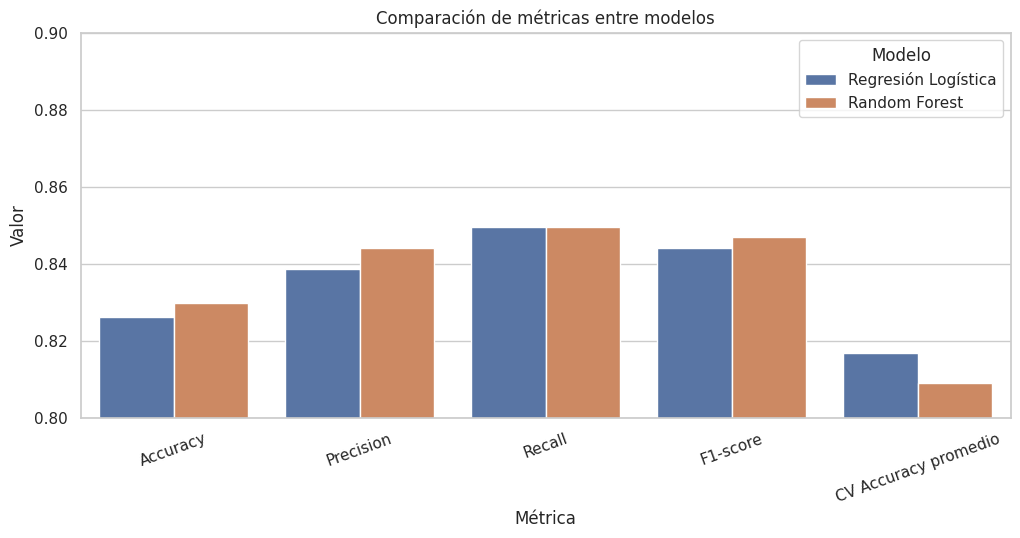

In [33]:
# Creamos una tabla comparativa final
comparacion_final = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_logistica, accuracy_rf],
    "Precision": [precision_logistica, precision_rf],
    "Recall": [recall_logistica, recall_rf],
    "F1-score": [f1_logistica, f1_rf],
    "CV Accuracy promedio": [cv_logistica.mean(), cv_rf.mean()],
    "CV Accuracy desvío": [cv_logistica.std(), cv_rf.std()]
})

# Mostramos la tabla redondeada
display(comparacion_final.round(3))

# Preparamos los datos para graficar
comparacion_grafico = comparacion_final.melt(
    id_vars="Modelo",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "CV Accuracy promedio"
    ],
    var_name="Métrica",
    value_name="Valor"
)

# Creamos el gráfico comparativo
plt.figure(figsize=(12, 5))

sns.barplot(
    data=comparacion_grafico,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

plt.title("Comparación de métricas entre modelos")
plt.xlabel("Métrica")
plt.ylabel("Valor")

# Ajustamos el eje Y para observar mejor diferencias pequeñas entre modelos.
# Como el eje no comienza en 0, las diferencias visuales pueden parecer más grandes.
plt.ylim(0.8, 0.9)

plt.xticks(rotation=20)
plt.legend(title="Modelo")
plt.show()

### Interpretación de la comparación visual

El gráfico permite comparar visualmente el rendimiento de la Regresión Logística y Random Forest en distintas métricas.

En las métricas calculadas sobre el conjunto de prueba, Random Forest obtiene resultados apenas superiores en accuracy, precision y F1-score. En recall, ambos modelos tienen el mismo valor.

Sin embargo, al observar el accuracy promedio de la validación cruzada, la Regresión Logística obtiene un resultado levemente superior. Esto indica que, al evaluar los modelos sobre distintas particiones del conjunto de entrenamiento, la Regresión Logística mostró un rendimiento promedio un poco más alto.

También es importante recordar que el eje vertical del gráfico comienza en 0.8 y no en 0. Esto permite ver mejor diferencias pequeñas, pero también puede hacer que esas diferencias parezcan más grandes visualmente. Por eso, siempre conviene interpretar el gráfico junto con la tabla de métricas.

En conjunto, la comparación muestra que ambos modelos tienen un rendimiento muy similar. Random Forest fue apenas mejor en la evaluación sobre el conjunto de prueba, pero la Regresión Logística fue levemente mejor y más estable en validación cruzada.

> **Sugerencia para tu proyecto:**  
> Cuando modifiques la escala de un gráfico para resaltar diferencias, aclaralo en la interpretación. Un gráfico debe ayudar a comprender los resultados, no exagerarlos.

## Curva ROC y AUC

Además de las métricas anteriores, podemos comparar los modelos usando la **curva ROC** y el valor **AUC**.

La curva ROC muestra la relación entre:

- la tasa de verdaderos positivos, es decir, los casos positivos que el modelo logra detectar correctamente;
- la tasa de falsos positivos, es decir, los casos negativos que el modelo clasifica incorrectamente como positivos.

El valor AUC resume esa curva en un solo número. Cuanto más cercano a 1 sea el AUC, mayor será la capacidad del modelo para distinguir entre las dos clases.

En esta sección vamos a calcular y graficar la curva ROC para Regresión Logística y Random Forest.

> **Sugerencia para tu proyecto:**  
> La curva ROC es especialmente útil cuando querés analizar la capacidad general del modelo para separar clases. No reemplaza a la matriz de confusión, pero agrega otra mirada sobre el rendimiento del modelo.

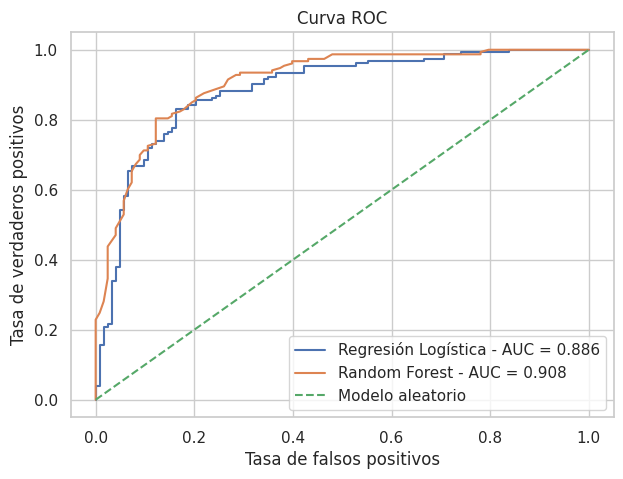

In [34]:
# Obtenemos las probabilidades de la clase positiva para cada modelo
y_prob_logistica = pipeline_logistica.predict_proba(X_test)[:, 1]
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Calculamos la curva ROC para Regresión Logística
fpr_logistica, tpr_logistica, _ = roc_curve(y_test, y_prob_logistica)
auc_logistica = roc_auc_score(y_test, y_prob_logistica)

# Calculamos la curva ROC para Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Graficamos ambas curvas ROC
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistica,
    tpr_logistica,
    label=f"Regresión Logística - AUC = {auc_logistica:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest - AUC = {auc_rf:.3f}"
)

# Línea de referencia de un modelo aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo aleatorio"
)

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

### Interpretación de la curva ROC y del AUC

La curva ROC muestra la capacidad de cada modelo para distinguir entre pacientes con y sin enfermedad cardíaca a medida que cambia el umbral de decisión.

En este caso, los valores AUC obtenidos fueron:

- **Regresión Logística:** 0.886
- **Random Forest:** 0.908

Ambos modelos superan ampliamente la línea diagonal del modelo aleatorio, lo que indica que tienen una buena capacidad de discriminación.

Sin embargo, Random Forest obtiene un AUC más alto, lo que sugiere que, en términos generales, logra separar mejor las dos clases a lo largo de distintos umbrales de decisión.

Este resultado refuerza una idea que ya habíamos visto en otras métricas: Random Forest parece tener una ventaja leve en rendimiento sobre el conjunto de prueba. Aun así, esa ventaja debe interpretarse junto con la validación cruzada, donde la Regresión Logística mostró una leve mejor estabilidad y un accuracy promedio algo superior.

En otras palabras:

- **Random Forest** parece discriminar mejor entre clases en esta prueba;
- **Regresión Logística** parece un poco más estable en validación cruzada y más fácil de interpretar.

> **Sugerencia para tu proyecto:**  
> Si comparás varios modelos, no tomes una decisión usando una sola métrica. Un modelo puede tener mejor AUC, pero otro puede ser más estable, más interpretable o cometer menos errores del tipo que más te importa.

## Selección justificada del modelo

Después de entrenar y evaluar ambos modelos, podemos comparar sus resultados desde varias perspectivas.

En el conjunto de prueba, Random Forest obtuvo métricas apenas superiores a la Regresión Logística en accuracy, precision y F1-score. Además, también logró un AUC más alto, lo que indica una mejor capacidad general para distinguir entre pacientes con y sin enfermedad cardíaca.

Sin embargo, la validación cruzada mostró un resultado levemente más favorable para la Regresión Logística: tuvo un accuracy promedio un poco mayor y un desvío estándar menor. Esto sugiere que su rendimiento fue ligeramente más estable entre distintas particiones del conjunto de entrenamiento.

Por otro lado, la Regresión Logística tiene una ventaja importante: es más fácil de interpretar. En un contexto clínico, la interpretabilidad puede ser un criterio muy relevante, porque no solo importa que el modelo prediga bien, sino también que sus resultados puedan explicarse de manera comprensible.

Por lo tanto, una decisión razonable sería considerar ambos modelos como candidatos válidos:

- **Random Forest** puede ser preferible si se prioriza la capacidad predictiva y el AUC.
- **Regresión Logística** puede ser preferible si se prioriza la estabilidad, la simplicidad y la interpretabilidad.

Para este proyecto guía, seleccionaremos la **Regresión Logística** como modelo final, porque ofrece un rendimiento muy competitivo, fue levemente más estable en validación cruzada y resulta más sencilla de explicar en un contexto donde la interpretación del resultado es importante.

Esta elección no significa que Random Forest sea un mal modelo. De hecho, sus resultados fueron muy buenos. Simplemente estamos tomando una decisión fundamentada según el equilibrio entre rendimiento, estabilidad e interpretabilidad.

> **Sugerencia para tu proyecto:**  
> La selección del modelo debe estar justificada. No alcanza con decir “elegí este porque dio mejor accuracy”. Explicá qué métricas analizaste, qué errores te importan más y qué otros factores influyen en la decisión.

## Guardado del modelo final

Una vez seleccionado el modelo final, podemos guardarlo en un archivo para reutilizarlo más adelante sin tener que volver a entrenarlo desde cero.

En este caso, guardaremos el pipeline completo de Regresión Logística. Esto es importante porque el pipeline incluye tanto el preprocesamiento como el modelo entrenado.

Es decir, el archivo guardado no contendrá solamente el algoritmo, sino también todos los pasos necesarios para preparar nuevos datos antes de hacer predicciones.

Para guardar el modelo usaremos `joblib`, una herramienta muy utilizada para almacenar objetos de Python relacionados con Machine Learning.

> **Sugerencia para tu proyecto:**  
> Si guardás un modelo, asegurate de guardar también el preprocesamiento. Un modelo entrenado con datos escalados, imputados o codificados necesita recibir nuevos datos preparados de la misma manera.

In [35]:
# Importamos joblib para guardar el modelo entrenado
import joblib

# Definimos el nombre del archivo
nombre_modelo = "modelo_regresion_logistica_heart_disease.pkl"

# Guardamos el pipeline completo
joblib.dump(pipeline_logistica, nombre_modelo)

print(f"Modelo guardado como: {nombre_modelo}")

Modelo guardado como: modelo_regresion_logistica_heart_disease.pkl


### Interpretación del guardado del modelo

El modelo final fue guardado correctamente en el archivo `modelo_regresion_logistica_heart_disease.pkl`.

Este archivo contiene el pipeline completo, es decir:

- el preprocesamiento de variables numéricas;
- el preprocesamiento de variables categóricas;
- el modelo de Regresión Logística entrenado.

Guardar el pipeline completo es importante porque, si más adelante queremos usar el modelo con nuevos pacientes, esos datos deberán pasar por las mismas transformaciones que usamos durante el entrenamiento.

En un proyecto real, este archivo podría utilizarse para integrar el modelo en una aplicación, una API o un sistema de apoyo a la toma de decisiones. De todos modos, antes de usar un modelo en un contexto sensible como salud, sería necesario realizar muchas más validaciones técnicas, clínicas y éticas.

> **Sugerencia para tu proyecto:**  
> Guardar el modelo puede ser útil, pero no significa que esté listo para producción. Antes de usar un modelo en un entorno real, hay que validar su rendimiento con más datos, revisar sus errores y considerar el impacto de sus predicciones.

# Conclusiones finales

En este proyecto desarrollamos un flujo completo de Machine Learning aplicado a un dataset clínico sobre enfermedad cardíaca.

El objetivo fue construir un modelo capaz de predecir la presencia o ausencia de enfermedad cardíaca a partir de variables clínicas y demográficas de pacientes.

A lo largo del trabajo realizamos las siguientes etapas:

- cargamos el dataset desde Kaggle;
- exploramos su estructura general;
- analizamos valores faltantes, duplicados y tipos de variables;
- transformamos la variable objetivo original `num` en una variable binaria llamada `enfermedad`;
- realizamos análisis exploratorio sobre variables numéricas y categóricas;
- separamos variables predictoras y variable objetivo;
- dividimos los datos en entrenamiento y prueba;
- construimos un pipeline de preprocesamiento;
- entrenamos dos modelos de clasificación;
- evaluamos los modelos con métricas, matrices de confusión, validación cruzada y curva ROC;
- seleccionamos un modelo final de manera justificada;
- guardamos el pipeline entrenado para su posible reutilización.

Los resultados mostraron que tanto la Regresión Logística como Random Forest tuvieron un rendimiento sólido. Random Forest obtuvo resultados apenas superiores en algunas métricas del conjunto de prueba y un AUC más alto. Sin embargo, la Regresión Logística mostró un rendimiento muy competitivo, mayor estabilidad en validación cruzada y una interpretación más sencilla.

Por ese motivo, en este proyecto guía seleccionamos la Regresión Logística como modelo final.

Es importante destacar que este trabajo no debe interpretarse como un sistema médico listo para usar. Se trata de un ejercicio educativo de Machine Learning. Para aplicar un modelo en un contexto clínico real sería necesario contar con más validaciones, revisión profesional, análisis de sesgos, evaluación con nuevos datos y criterios éticos rigurosos.

> **Sugerencia para tu proyecto:**  
> En tus conclusiones no te limites a decir qué modelo ganó. Explicá qué hiciste, qué resultados obtuviste, qué limitaciones encontraste y qué mejoras podrían realizarse en una próxima etapa.

## Limitaciones y posibles mejoras

Aunque el proyecto permitió construir y evaluar modelos con buenos resultados, todavía existen varias limitaciones que conviene reconocer.

En primer lugar, el dataset contiene valores faltantes en algunas variables importantes, especialmente en `ca`, `thal` y `slope`. En este cuaderno decidimos conservar esas columnas e imputar sus valores dentro del pipeline, pero en otro análisis podría compararse el rendimiento del modelo eliminando algunas de esas variables o usando estrategias de imputación más avanzadas.

También observamos valores llamativos en algunas variables numéricas, como `chol` y `trestbps`, donde aparecen registros con valores iguales o cercanos a 0. En un proyecto real, estos casos deberían revisarse con mayor profundidad para determinar si representan errores de carga, valores faltantes codificados de otra manera o situaciones clínicamente válidas.

Otra limitación es que trabajamos con una versión binaria de la variable objetivo. Esto simplifica el problema, pero pierde información sobre los distintos niveles de enfermedad cardíaca que estaban representados originalmente en `num`.

Como posibles mejoras futuras, se podrían realizar las siguientes acciones:

- probar otros modelos, como KNN, SVM, Árbol de Decisión o Gradient Boosting;
- ajustar hiperparámetros con `GridSearchCV` o `RandomizedSearchCV`;
- comparar modelos con y sin las columnas con muchos valores faltantes;
- analizar con más detalle los valores atípicos o clínicamente sospechosos;
- evaluar métricas adicionales según el objetivo del proyecto;
- estudiar la importancia de las variables;
- probar una clasificación multiclase usando los valores originales de `num`.

Reconocer las limitaciones no debilita el proyecto. Al contrario, muestra que el análisis fue realizado con mirada crítica y que los resultados no se interpretan de manera automática o exagerada.

> **Sugerencia para tu proyecto:**  
> Todo proyecto tiene límites. Mencionarlos demuestra criterio profesional. Una buena conclusión reconoce qué se logró, pero también qué falta revisar, mejorar o validar.

# Anexo final y referencias

## Dataset utilizado

El dataset utilizado en este proyecto es **Heart Disease Data**, disponible en Kaggle:

https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

Este conjunto de datos contiene información clínica de pacientes evaluados por posible enfermedad cardíaca. Incluye variables como edad, sexo, tipo de dolor en el pecho, presión arterial en reposo, colesterol, frecuencia cardíaca máxima alcanzada, resultados de estudios médicos y diagnóstico asociado a enfermedad cardíaca.

## Variable objetivo

La variable original `num` indica distintos niveles de presencia de enfermedad cardíaca, con valores entre 0 y 4.

Para este proyecto se transformó en una variable binaria llamada `enfermedad`:

- `0`: ausencia de enfermedad cardíaca;
- `1`: presencia de enfermedad cardíaca.

## Aclaraciones sobre el enfoque

Este notebook fue desarrollado como una guía modelo para organizar un Proyecto Integrador de Machine Learning.

El objetivo no fue construir un sistema médico real, sino recorrer de manera ordenada las etapas principales de un proyecto supervisado:

- exploración de datos;
- limpieza y preprocesamiento;
- construcción de pipelines;
- entrenamiento de modelos;
- evaluación con métricas;
- validación cruzada;
- comparación de modelos;
- interpretación de resultados;
- conclusiones y mejoras posibles.

## Recomendación final

En tu propio Proyecto Integrador, recordá adaptar esta estructura a tu dataset y a tu problema específico. No todos los proyectos requieren exactamente los mismos gráficos, las mismas transformaciones o los mismos modelos.

Lo importante es que cada decisión esté explicada y justificada.

> **Sugerencia para tu proyecto:**  
> El anexo final es un buen lugar para incluir el enlace al dataset, referencias consultadas, aclaraciones sobre columnas, decisiones especiales y cualquier información adicional que ayude a entender o reproducir tu trabajo.